## Graphs for multi-label classification

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    'font.size': 12,          # Base font size for regular text
    'axes.titlesize': 16,     # Font size for the plot title (Panel A, Panel B)
    'axes.labelsize': 14,     # Font size for X and Y axis labels (Epoch, Metric)
    'xtick.labelsize': 12,    # Font size for the X-axis numbers (1, 2, 3...)
    'ytick.labelsize': 12,    # Font size for the Y-axis numbers (0.5, 1.0...)
    'legend.fontsize': 11,    # Font size for the legend text
    'figure.titlesize': 18    # Font size for the main overarching figure title
})

### First try baseline

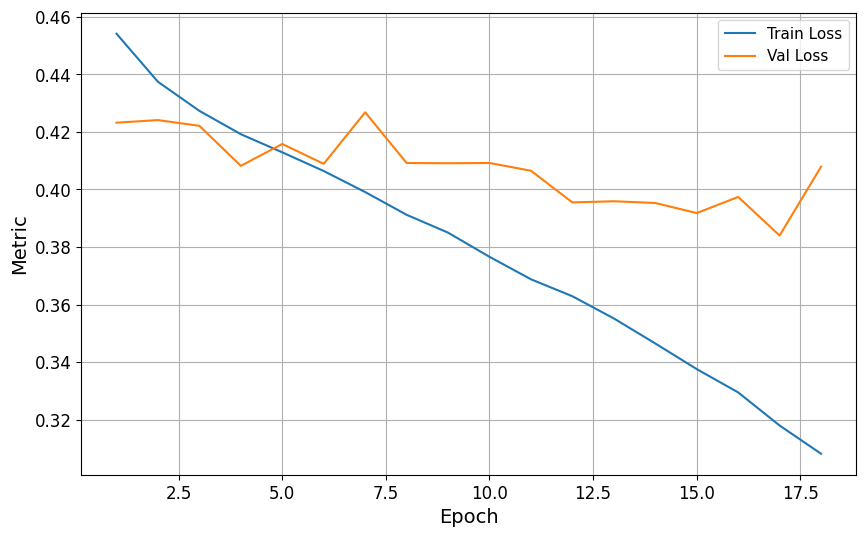

In [2]:
epochs_1 = np.arange(1, 19, 1)
train_loss_1 = np.array([0.4541, 0.4374, 0.4273, 0.4192, 0.4129, 0.4064, 0.3991, 0.3912, 0.3850, 0.3766, 0.3688, 0.3629, 0.3552, 0.3465, 0.3376, 0.3295, 0.3180, 0.3082])
val_loss_1 = np.array([0.4232, 0.4241, 0.4221, 0.4082, 0.4158, 0.4089, 0.4268, 0.4092, 0.4091, 0.4092, 0.4065, 0.3955, 0.3959, 0.3953, 0.3918, 0.3974, 0.3840, 0.4079])

plt.figure(figsize=(10,6))

plt.plot(epochs_1, train_loss_1, label="Train Loss")
plt.plot(epochs_1, val_loss_1, label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.legend()
plt.grid(True)

plt.show()

## Second try baseline

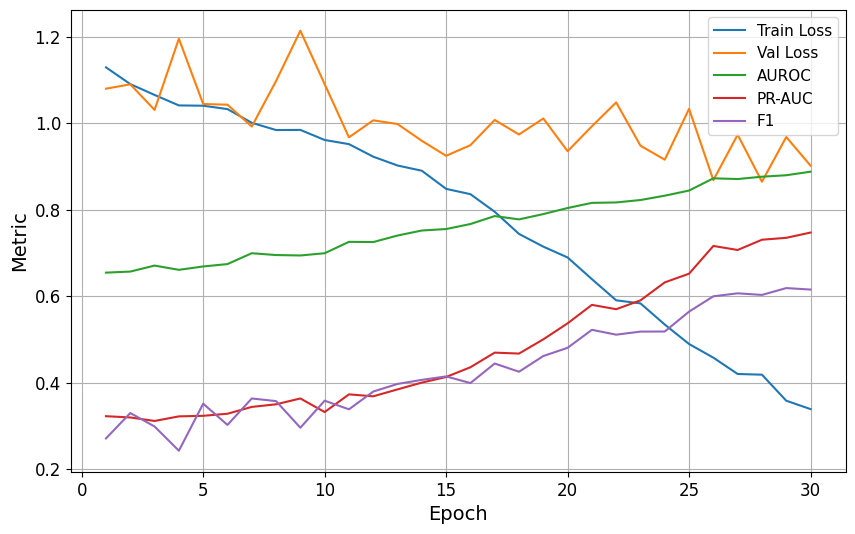

In [3]:
epochs_2 = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])
train_loss_2 = np.array([
    1.1290, 1.0903, 1.0652, 1.0410, 1.0403,
    1.0325, 1.0008, 0.9841, 0.9844, 0.9611,
    0.9515, 0.9225, 0.9021, 0.8900, 0.8481,
    0.8358, 0.7951, 0.7439, 0.7145, 0.6895,
    0.6394, 0.5904, 0.5833, 0.5344, 0.4894,
    0.4578, 0.4201, 0.4185, 0.3583, 0.3389
])
val_loss_2 = np.array([
    1.0797, 1.0898, 1.0306, 1.1953, 1.0442,
    1.0427, 0.9922, 1.0975, 1.2137, 1.0902,
    0.9672, 1.0065, 0.9980, 0.9592, 0.9245,
    0.9491, 1.0074, 0.9738, 1.0108, 0.9352,
    0.9927, 1.0480, 0.9479, 0.9155, 1.0331,
    0.8682, 0.9733, 0.8646, 0.9680, 0.9018
])
auroc_2 = np.array([
    0.6544, 0.6569, 0.6707, 0.6609, 0.6687,
    0.6742, 0.6993, 0.6951, 0.6941, 0.6993,
    0.7256, 0.7251, 0.7402, 0.7518, 0.7552,
    0.7668, 0.7852, 0.7775, 0.7898, 0.8038,
    0.8157, 0.8167, 0.8223, 0.8323, 0.8442,
    0.8725, 0.8708, 0.8762, 0.8796, 0.8878
])
pr_auc_2 = np.array([
    0.3225, 0.3196, 0.3115, 0.3221, 0.3234,
    0.3282, 0.3440, 0.3500, 0.3635, 0.3321,
    0.3730, 0.3685, 0.3845, 0.4002, 0.4131,
    0.4357, 0.4695, 0.4673, 0.5002, 0.5372,
    0.5799, 0.5699, 0.5903, 0.6319, 0.6520,
    0.7161, 0.7068, 0.7305, 0.7349, 0.7471
])
f1_2 = np.array([
    0.2712, 0.3298, 0.2987, 0.2427, 0.3514,
    0.3024, 0.3635, 0.3574, 0.2959, 0.3584,
    0.3384, 0.3795, 0.3971, 0.4065, 0.4145,
    0.3991, 0.4443, 0.4253, 0.4616, 0.4806,
    0.5222, 0.5110, 0.5181, 0.5183, 0.5643,
    0.5997, 0.6066, 0.6029, 0.6187, 0.6153
])

plt.figure(figsize=(10,6))

plt.plot(epochs_2, train_loss_2, label="Train Loss")
plt.plot(epochs_2, val_loss_2, label="Val Loss")
plt.plot(epochs_2, auroc_2, label="AUROC")
plt.plot(epochs_2, pr_auc_2, label="PR-AUC")
plt.plot(epochs_2, f1_2, label="F1")

plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.legend()
plt.grid(True)

plt.show()

## Fix data leakage 

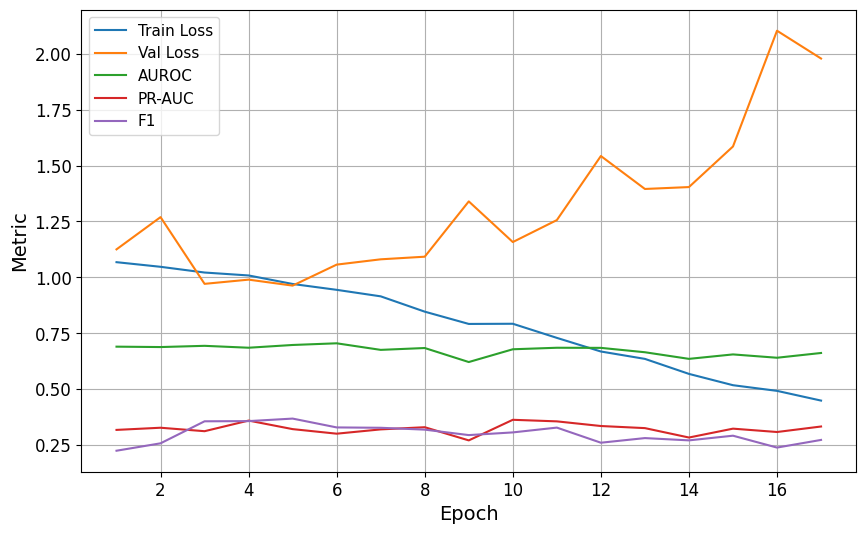

In [4]:
epochs_3 = np.array([
    1, 2, 3, 4, 5, 6, 7, 8, 9,
    10, 11, 12, 13, 14, 15, 16, 17
])

train_loss_3 = np.array([
    1.0678, 1.0471, 1.0215, 1.0084, 0.9703,
    0.9441, 0.9150, 0.8465, 0.7916,
    0.7924, 0.7293, 0.6683, 0.6353,
    0.5682, 0.5176, 0.4923, 0.4488
])

val_loss_3  = np.array([
    1.1251, 1.2693, 0.9709, 0.9897, 0.9630,
    1.0569, 1.0806, 1.0923, 1.3396,
    1.1578, 1.2560, 1.5426, 1.3952,
    1.4037, 1.5852, 2.1029, 1.9785
])

auroc_3 = np.array([
    0.6900, 0.6882, 0.6937, 0.6852, 0.6975,
    0.7050, 0.6756, 0.6839, 0.6212,
    0.6783, 0.6851, 0.6846, 0.6650,
    0.6354, 0.6553, 0.6404, 0.6617
])

pr_auc_3 = np.array([
    0.3177, 0.3274, 0.3119, 0.3594, 0.3212,
    0.3008, 0.3200, 0.3297, 0.2708,
    0.3629, 0.3559, 0.3351, 0.3257,
    0.2836, 0.3233, 0.3083, 0.3329
])

f1_3 = np.array([
    0.2246, 0.2577, 0.3562, 0.3570, 0.3683,
    0.3288, 0.3272, 0.3189, 0.2945,
    0.3065, 0.3280, 0.2604, 0.2811,
    0.2709, 0.2918, 0.2387, 0.2729
])

plt.figure(figsize=(10,6))

plt.plot(epochs_3, train_loss_3, label="Train Loss")
plt.plot(epochs_3, val_loss_3, label="Val Loss")
plt.plot(epochs_3, auroc_3, label="AUROC")
plt.plot(epochs_3, pr_auc_3, label="PR-AUC")
plt.plot(epochs_3, f1_3, label="F1")

plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.legend()
plt.grid(True)

plt.show()

## Different Windowing

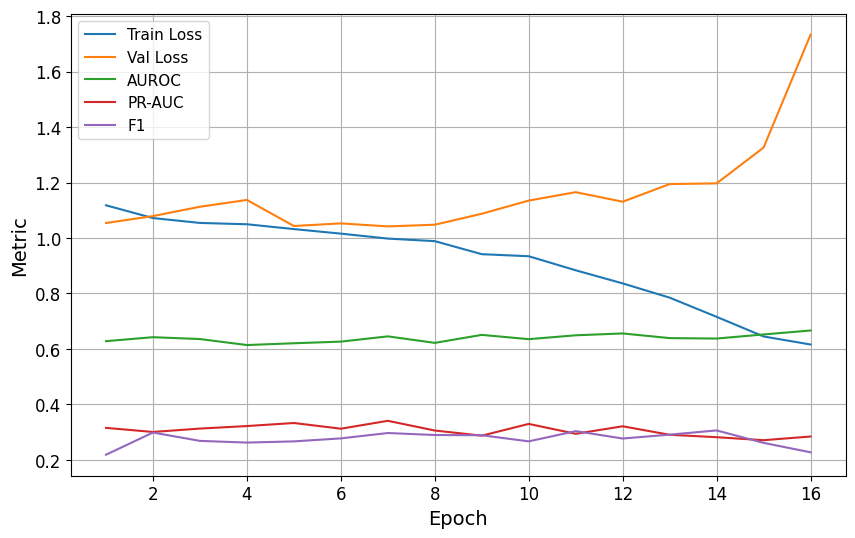

In [5]:
epochs_4 = np.array([
    1, 2, 3, 4, 5, 6, 7, 8,
    9, 10, 11, 12, 13, 14, 15, 16
])

train_loss_4 = np.array([
    1.1179, 1.0718, 1.0543, 1.0495,
    1.0321, 1.0157, 0.9978, 0.9886,
    0.9416, 0.9342, 0.8835, 0.8362,
    0.7848, 0.7156, 0.6448, 0.6158
])

val_loss_4 = np.array([
    1.0540, 1.0790, 1.1127, 1.1372,
    1.0432, 1.0527, 1.0417, 1.0479,
    1.0874, 1.1349, 1.1652, 1.1308,
    1.1944, 1.1970, 1.3260, 1.7331
])

auroc_4 = np.array([
    0.6279, 0.6422, 0.6355, 0.6139,
    0.6203, 0.6262, 0.6452, 0.6217,
    0.6505, 0.6351, 0.6490, 0.6557,
    0.6389, 0.6373, 0.6521, 0.6663
])

pr_auc_4 = np.array([
    0.3151, 0.3004, 0.3126, 0.3217,
    0.3327, 0.3122, 0.3406, 0.3056,
    0.2870, 0.3294, 0.2938, 0.3209,
    0.2902, 0.2815, 0.2707, 0.2840
])

f1_4 = np.array([
    0.2183, 0.2983, 0.2682, 0.2621,
    0.2664, 0.2772, 0.2966, 0.2894,
    0.2885, 0.2665, 0.3034, 0.2767,
    0.2907, 0.3059, 0.2611, 0.2270
])

plt.figure(figsize=(10,6))

plt.plot(epochs_4, train_loss_4, label="Train Loss")
plt.plot(epochs_4, val_loss_4, label="Val Loss")
plt.plot(epochs_4, auroc_4, label="AUROC")
plt.plot(epochs_4, pr_auc_4, label="PR-AUC")
plt.plot(epochs_4, f1_4, label="F1")

plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.legend()
plt.grid(True)

plt.show()

## Train Loss

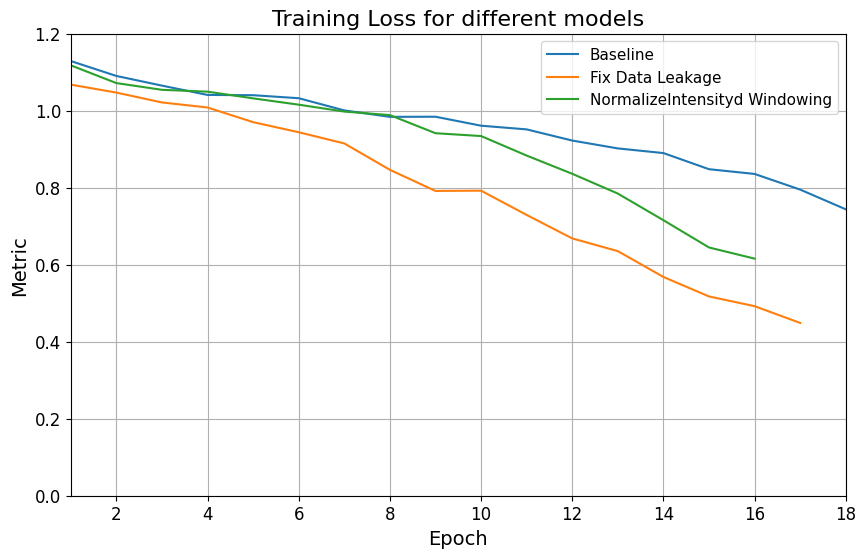

In [6]:
plt.figure(figsize=(10,6))

plt.plot(epochs_2, train_loss_2, label="Baseline")
plt.plot(epochs_3, train_loss_3, label="Fix Data Leakage")
plt.plot(epochs_4, train_loss_4, label="NormalizeIntensityd Windowing")

plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title('Training Loss for different models')
plt.legend()
plt.xlim(1, 18)
plt.ylim(0, 1.2)
plt.grid(True)

plt.show()

## Validation Loss

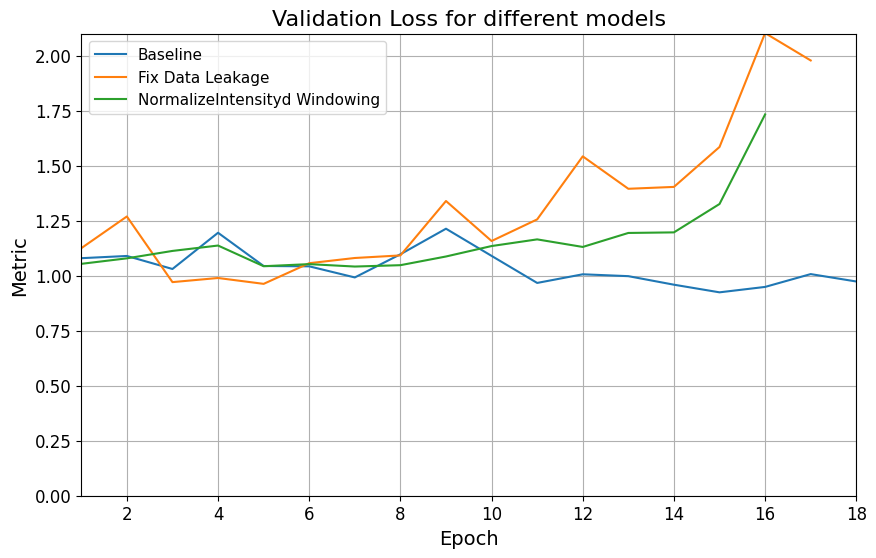

In [7]:
plt.figure(figsize=(10,6))

plt.plot(epochs_2, val_loss_2, label="Baseline")
plt.plot(epochs_3, val_loss_3, label="Fix Data Leakage")
plt.plot(epochs_4, val_loss_4, label="NormalizeIntensityd Windowing")

plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title('Validation Loss for different models')
plt.legend()
plt.xlim(1, 18)
plt.ylim(0, 2.1)
plt.grid(True)

plt.show()

## AUROC

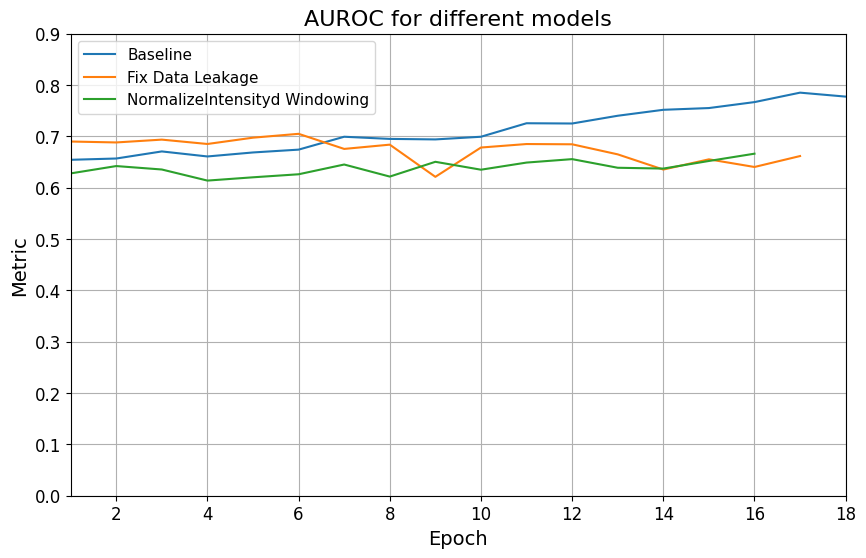

In [8]:
plt.figure(figsize=(10,6))

plt.plot(epochs_2, auroc_2, label="Baseline")
plt.plot(epochs_3, auroc_3, label="Fix Data Leakage")
plt.plot(epochs_4, auroc_4, label="NormalizeIntensityd Windowing")

plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title('AUROC for different models')
plt.xlim(1, 18)
plt.ylim(0, 0.9)
plt.legend()
plt.grid(True)

plt.show()

## pr-auc

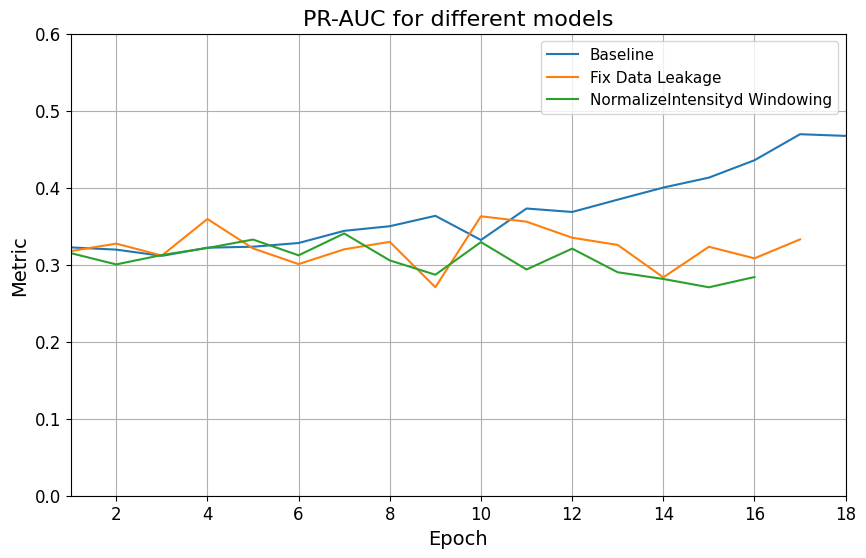

In [9]:
plt.figure(figsize=(10,6))

plt.plot(epochs_2, pr_auc_2, label="Baseline")
plt.plot(epochs_3, pr_auc_3, label="Fix Data Leakage")
plt.plot(epochs_4, pr_auc_4, label="NormalizeIntensityd Windowing")

plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title('PR-AUC for different models')
plt.legend()
plt.xlim(1, 18)
plt.ylim(0, 0.6)
plt.grid(True)

plt.show()

## F1 - Score

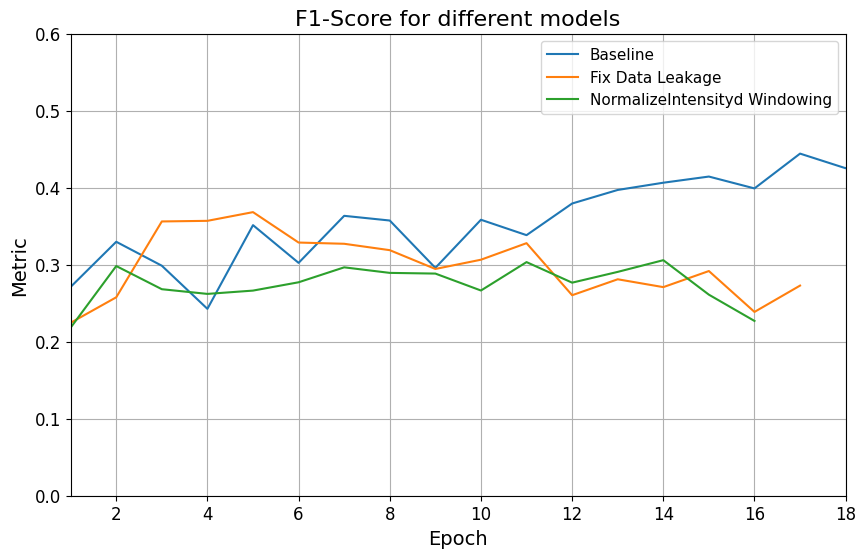

In [10]:
plt.figure(figsize=(10,6))

plt.plot(epochs_2, f1_2, label="Baseline")
plt.plot(epochs_3, f1_3, label="Fix Data Leakage")
plt.plot(epochs_4, f1_4, label="NormalizeIntensityd Windowing")

plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title('F1-Score for different models')
plt.legend()
plt.xlim(1, 18)
plt.ylim(0, 0.6)
plt.grid(True)

plt.show()

## Heatmap

In [11]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from monai.networks.nets import resnet50
from monai.visualize import GradCAM
from monai.transforms import Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd, Resized, NormalizeIntensityd, EnsureTyped


c:\Users\alvap\OneDrive\Documents\MSc\Data-Challenges_RDGY41850\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
#set up device and load the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = resnet50(spatial_dims=3, n_input_channels=1, num_classes=18).to(device)

#load saved weights from training
model.load_state_dict(torch.load("../Weights_best_models/resnet50_v2_best.pth", map_location=device))
model.eval()

#initialise GradCAM with the model and target layer
#layer4 is final convolutional layer in resnet50
cam = GradCAM(nn_module=model, target_layers="layer4")

#load a single sample volume
test_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Orientationd(keys=["image"], axcodes="RAS"),
    Spacingd(
        keys=["image"],
        pixdim=(2.0, 2.0, 2.0),
        mode="bilinear"
    ),
    Resized(
        keys=["image"],
        spatial_size=(128, 128, 128)
    ),
    NormalizeIntensityd(
        keys=["image"],
        nonzero=True
    ),
    EnsureTyped(keys=["image"])
])
sample_data = test_transforms({'image': "../dataset/CT-RATE-sample/dataset/train/train_1/train_1_a/train_1_a_1.nii.gz"})
input_tensor = sample_data["image"].unsqueeze(0).to(device)

In [13]:
#check what abnormalities are present in the sample
# Load the spreadsheet
csv_path = "../dataset/CT-RATE-sample/dataset/multi_abnormality_labels/train_predicted_labels.csv"
df = pd.read_csv(csv_path)

# Look for the row that matches file
# Add the extension to your search string
patient_id = "train_1_a_1.nii.gz"
patient_row = df[df['VolumeName'] == patient_id]

print(f"Findings for {patient_id}:")
# Setting transpose (.T) makes it much easier to read the list of diseases
print(patient_row.T)

Findings for train_1_a_1.nii.gz:
                                                     0
VolumeName                          train_1_a_1.nii.gz
Medical material                                     0
Arterial wall calcification                          1
Cardiomegaly                                         0
Pericardial effusion                                 0
Coronary artery wall calcification                   0
Hiatal hernia                                        0
Lymphadenopathy                                      0
Emphysema                                            0
Atelectasis                                          1
Lung nodule                                          0
Lung opacity                                         1
Pulmonary fibrotic sequela                           0
Pleural effusion                                     0
Mosaic attenuation pattern                           0
Peribronchial thickening                             1
Consolidation                   

In [14]:
# generate 3D heatmaps for two different diseases
# 1 = Arterial wall calcification, 15 = Consolidation
target_classes = {"Calcification": 1, "Consolidation": 15}
heatmaps = {}

for class_name, class_idx in target_classes.items():
    heatmap_3d = cam(x=input_tensor, class_idx=class_idx)
    heatmaps[class_name] = heatmap_3d[0, 0].cpu().numpy()

image_np = input_tensor[0, 0].cpu().numpy()

#extract middle slise 
slice_idx = image_np.shape[2] // 2
img_slice = image_np[:, :, slice_idx]

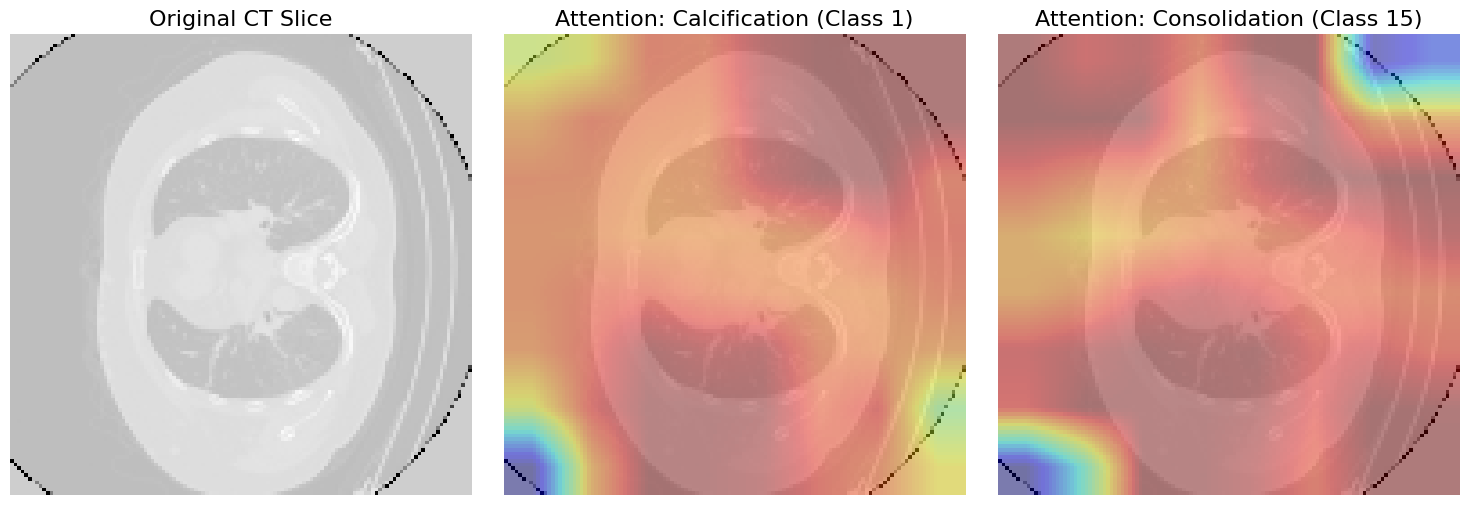

In [16]:
# plot a 1-row, 3-column comparison figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# extract the matching middle slice for both heatmaps
map_calcification = heatmaps["Calcification"][:, :, slice_idx]
map_consolidation = heatmaps["Consolidation"][:, :, slice_idx]

#  1 - Original Image
axes[0].imshow(img_slice, cmap="gray")
axes[0].set_title("Original CT Slice")
axes[0].axis("off")

# 2 - Calcification Attention
axes[1].imshow(img_slice, cmap="gray")
axes[1].imshow(map_calcification, cmap="jet", alpha=0.4)
axes[1].set_title("Attention: Calcification (Class 1)")
axes[1].axis("off")



# 3 - Consolidation Attention
axes[2].imshow(img_slice, cmap="gray")
axes[2].imshow(map_consolidation, cmap="jet", alpha=0.4)
axes[2].set_title("Attention: Consolidation (Class 15)")
axes[2].axis("off")

plt.tight_layout()

## Long Paper

In [17]:
epochs_5 = np.arange(1, 31, 1)  # all four Model 4/5 runs completed the full 30 epochs

train_loss_model4_mw = np.array([1.1378, 1.1255, 1.1039, 1.0797, 1.0612, 1.0497, 1.0322, 1.0266, 1.0094, 1.0119, 1.0127, 1.0021, 0.9931, 0.9974, 0.9896, 0.9814, 0.9724, 0.9689, 0.9724, 0.9629, 0.9635, 0.958, 0.9668, 0.9561, 0.9571, 0.9554, 0.9578, 0.9413, 0.9437, 0.9264])
val_loss_model4_mw = np.array([1.066, 1.057, 1.0371, 1.0199, 1.0079, 0.9972, 0.9997, 0.9934, 0.9874, 0.9823, 0.9787, 0.9745, 0.9763, 0.9725, 0.9732, 0.974, 0.9688, 0.9665, 0.9617, 0.9703, 0.966, 0.9625, 0.9595, 0.9614, 0.9592, 0.9648, 0.9616, 0.9579, 0.9633, 0.9635])
auroc_model4_mw = np.array([0.5744, 0.6338, 0.6535, 0.6695, 0.673, 0.6816, 0.6686, 0.6761, 0.6781, 0.6811, 0.6875, 0.6872, 0.6859, 0.6864, 0.6885, 0.6855, 0.6894, 0.6926, 0.6966, 0.6881, 0.6946, 0.6958, 0.6986, 0.7015, 0.7006, 0.6934, 0.6976, 0.6976, 0.6966, 0.6919])
pr_auc_model4_mw = np.array([0.2619, 0.2943, 0.3095, 0.3228, 0.3316, 0.3383, 0.3336, 0.3361, 0.3523, 0.3426, 0.3471, 0.3427, 0.3641, 0.3627, 0.3492, 0.3537, 0.3608, 0.347, 0.36, 0.3483, 0.3619, 0.3549, 0.3554, 0.36, 0.3581, 0.3549, 0.3589, 0.3479, 0.366, 0.3528])
f1_model4_mw = np.array([0.269, 0.2842, 0.3036, 0.3237, 0.33, 0.3246, 0.3157, 0.3317, 0.3232, 0.3324, 0.3401, 0.335, 0.3309, 0.3423, 0.3489, 0.3381, 0.3367, 0.3456, 0.348, 0.3479, 0.3462, 0.3508, 0.3535, 0.3543, 0.3511, 0.3542, 0.348, 0.3516, 0.3448, 0.3477])

train_loss_model4_sw = np.array([1.1377, 1.128, 1.1187, 1.1059, 1.0866, 1.0754, 1.0582, 1.0461, 1.0399, 1.0305, 1.0308, 1.007, 1.0138, 0.997, 1.0063, 1.0002, 0.9936, 0.992, 0.9862, 0.9784, 0.9745, 0.9718, 0.9723, 0.9611, 0.9662, 0.9635, 0.964, 0.9571, 0.9361, 0.9451])
val_loss_model4_sw = np.array([1.067, 1.063, 1.0533, 1.0427, 1.0322, 1.0283, 1.0282, 1.0254, 1.0212, 1.0189, 1.018, 1.0139, 1.012, 1.014, 1.0162, 1.0056, 1.0067, 1.0088, 1.0032, 1.0056, 1.004, 1.0073, 1.0034, 1.0084, 1.0031, 1.0042, 1.0087, 1.0074, 1.0057, 1.0073])
auroc_model4_sw = np.array([0.5402, 0.5745, 0.6061, 0.619, 0.6345, 0.6267, 0.6218, 0.6296, 0.6314, 0.6322, 0.6379, 0.6365, 0.6392, 0.6384, 0.6426, 0.6516, 0.6491, 0.6519, 0.6553, 0.6505, 0.652, 0.6512, 0.658, 0.6535, 0.6569, 0.659, 0.6532, 0.6566, 0.6564, 0.6557])
pr_auc_model4_sw = np.array([0.2535, 0.2734, 0.2957, 0.2992, 0.3041, 0.3024, 0.2887, 0.2995, 0.3008, 0.3052, 0.3075, 0.3068, 0.3118, 0.3143, 0.3125, 0.3178, 0.3235, 0.3227, 0.3305, 0.3237, 0.3248, 0.3279, 0.3294, 0.3367, 0.3239, 0.3314, 0.3281, 0.3316, 0.3253, 0.3286])
f1_model4_sw = np.array([0.2668, 0.2586, 0.2825, 0.3155, 0.2987, 0.3055, 0.3059, 0.3292, 0.3239, 0.3287, 0.3208, 0.3248, 0.3274, 0.3275, 0.3303, 0.3382, 0.3232, 0.3356, 0.3359, 0.3359, 0.3289, 0.3263, 0.3246, 0.3277, 0.3303, 0.3298, 0.3306, 0.3245, 0.3281, 0.3254])

train_loss_model4_ft = np.array([1.0972, 0.9695, 0.8965, 0.832, 0.7869, 0.7146, 0.6605, 0.6105, 0.5599, 0.5545, 0.483, 0.4278, 0.4097, 0.3561, 0.3703, 0.307, 0.2546, 0.2195, 0.2633, 0.2353, 0.2211, 0.2027, 0.1676, 0.1596, 0.1294, 0.1476, 0.1572, 0.1245, 0.0991, 0.1047])
val_loss_model4_ft = np.array([0.9919, 0.9376, 0.9349, 0.9473, 1.0458, 0.9703, 0.9232, 1.0695, 1.1251, 1.2176, 1.2701, 1.3354, 1.5127, 1.154, 1.8744, 1.7809, 1.9229, 1.8103, 2.501, 1.9811, 2.1414, 2.4077, 2.6658, 2.3141, 2.5767, 2.7842, 2.5716, 2.8576, 2.6533, 2.7466])
auroc_model4_ft = np.array([0.7145, 0.749, 0.7465, 0.751, 0.7357, 0.7591, 0.7788, 0.7737, 0.7545, 0.7474, 0.7229, 0.7541, 0.7177, 0.747, 0.702, 0.7022, 0.6973, 0.6803, 0.6874, 0.6879, 0.6597, 0.6829, 0.6548, 0.6757, 0.6621, 0.6676, 0.6731, 0.6655, 0.6901, 0.6727])
pr_auc_model4_ft = np.array([0.3705, 0.3907, 0.3738, 0.3824, 0.4222, 0.4143, 0.4391, 0.4196, 0.3934, 0.3979, 0.3983, 0.3921, 0.3858, 0.3838, 0.3686, 0.4055, 0.3773, 0.4085, 0.3849, 0.3844, 0.3755, 0.3966, 0.3636, 0.3958, 0.38, 0.3757, 0.3872, 0.3793, 0.407, 0.3845])
f1_model4_ft = np.array([0.3199, 0.3943, 0.3847, 0.3698, 0.3541, 0.3887, 0.4105, 0.4024, 0.3643, 0.376, 0.3825, 0.3596, 0.3244, 0.3652, 0.3362, 0.3448, 0.3392, 0.4006, 0.3316, 0.3354, 0.3184, 0.3271, 0.3051, 0.3596, 0.3317, 0.2806, 0.3188, 0.3076, 0.372, 0.287])

train_loss_model5_mw = np.array([1.1353, 1.1018, 1.0896, 1.0667, 1.0618, 1.0452, 1.032, 1.0353, 1.0129, 0.9908, 0.9796, 0.98, 0.974, 0.977, 0.934, 0.9103, 0.8714, 0.8638, 0.8223, 0.8063, 0.758, 0.7467, 0.7058, 0.656, 0.6468, 0.6345, 0.5618, 0.5384, 0.5243, 0.5175])
val_loss_model5_mw = np.array([1.0493, 1.0752, 1.2178, 3.0024, 0.9963, 1.1824, 1.0338, 0.9991, 1.1007, 1.1408, 0.9932, 1.0368, 0.9497, 1.036, 1.0189, 1.0281, 0.9894, 1.1056, 1.0567, 1.1103, 1.1916, 1.1603, 1.171, 1.4733, 1.2849, 1.3733, 1.4116, 1.396, 1.3554, 1.5198])
auroc_model5_mw = np.array([0.6523, 0.6624, 0.659, 0.6408, 0.6764, 0.6483, 0.667, 0.6825, 0.6736, 0.6738, 0.6713, 0.689, 0.6887, 0.6931, 0.6976, 0.6987, 0.6874, 0.6733, 0.657, 0.6477, 0.6797, 0.6859, 0.6757, 0.6098, 0.6655, 0.6541, 0.6705, 0.667, 0.6655, 0.667])
pr_auc_model5_mw = np.array([0.2972, 0.2849, 0.3081, 0.3314, 0.3085, 0.2874, 0.3032, 0.3097, 0.3265, 0.3219, 0.3054, 0.3486, 0.3146, 0.3119, 0.4005, 0.3193, 0.3498, 0.3298, 0.2922, 0.3042, 0.3149, 0.3268, 0.3421, 0.3007, 0.3352, 0.3706, 0.3973, 0.3609, 0.3873, 0.3704])
f1_model5_mw = np.array([0.2243, 0.2447, 0.2218, 0.1058, 0.3038, 0.2648, 0.3002, 0.3066, 0.2561, 0.2957, 0.2958, 0.3094, 0.3634, 0.3258, 0.3269, 0.334, 0.3408, 0.3261, 0.3291, 0.3347, 0.367, 0.3212, 0.3269, 0.2799, 0.3449, 0.3487, 0.3037, 0.3374, 0.3467, 0.3755])


### Train Loss

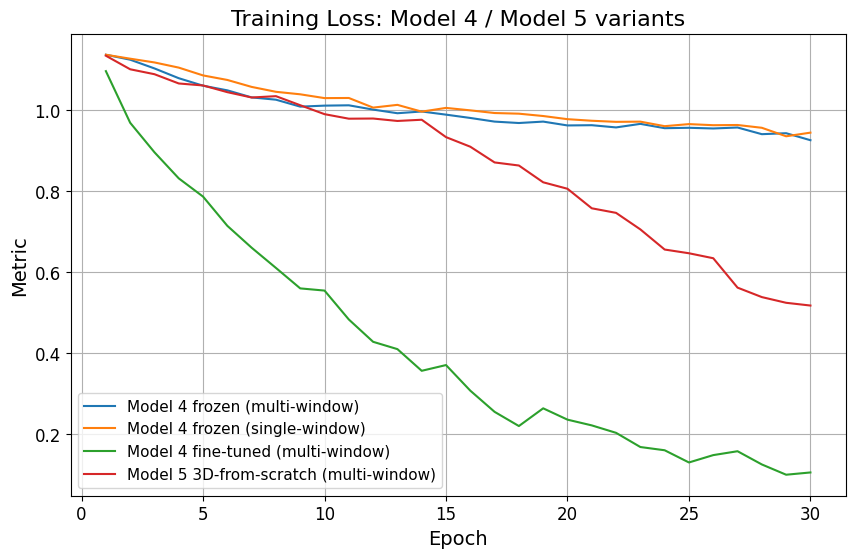

In [18]:
plt.figure(figsize=(10,6))

plt.plot(epochs_5, train_loss_model4_mw, label="Model 4 frozen (multi-window)")
plt.plot(epochs_5, train_loss_model4_sw, label="Model 4 frozen (single-window)")
plt.plot(epochs_5, train_loss_model4_ft, label="Model 4 fine-tuned (multi-window)")
plt.plot(epochs_5, train_loss_model5_mw, label="Model 5 3D-from-scratch (multi-window)")

plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title('Training Loss: Model 4 / Model 5 variants')
plt.legend()
plt.grid(True)

plt.show()

### Validation Loss

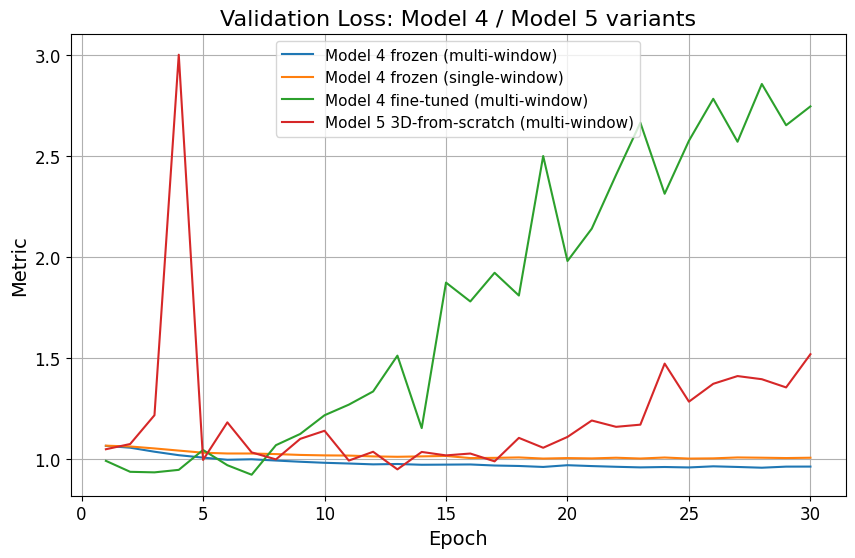

In [19]:
plt.figure(figsize=(10,6))

plt.plot(epochs_5, val_loss_model4_mw, label="Model 4 frozen (multi-window)")
plt.plot(epochs_5, val_loss_model4_sw, label="Model 4 frozen (single-window)")
plt.plot(epochs_5, val_loss_model4_ft, label="Model 4 fine-tuned (multi-window)")
plt.plot(epochs_5, val_loss_model5_mw, label="Model 5 3D-from-scratch (multi-window)")

plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title('Validation Loss: Model 4 / Model 5 variants')
plt.legend()
plt.grid(True)

plt.show()

## AUROC

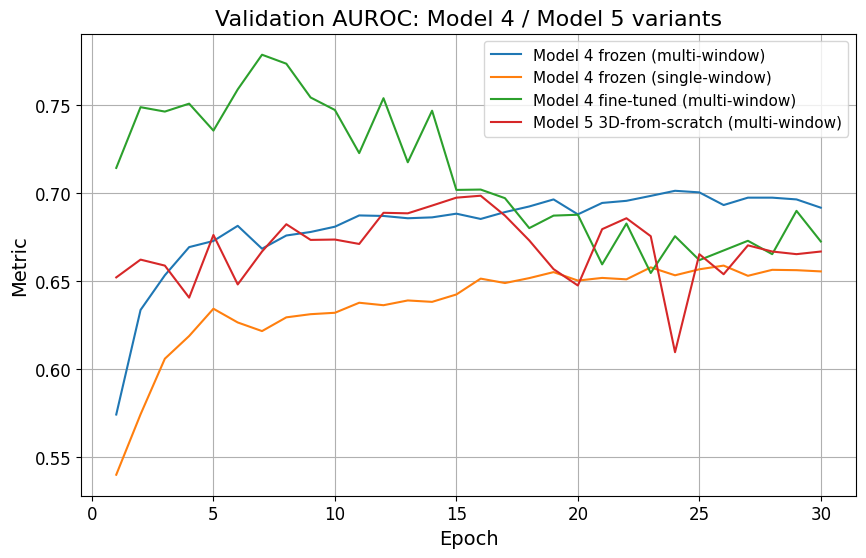

In [20]:
plt.figure(figsize=(10,6))

plt.plot(epochs_5, auroc_model4_mw, label="Model 4 frozen (multi-window)")
plt.plot(epochs_5, auroc_model4_sw, label="Model 4 frozen (single-window)")
plt.plot(epochs_5, auroc_model4_ft, label="Model 4 fine-tuned (multi-window)")
plt.plot(epochs_5, auroc_model5_mw, label="Model 5 3D-from-scratch (multi-window)")

plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title('Validation AUROC: Model 4 / Model 5 variants')
plt.legend()
plt.grid(True)

plt.show()

## pr- auc

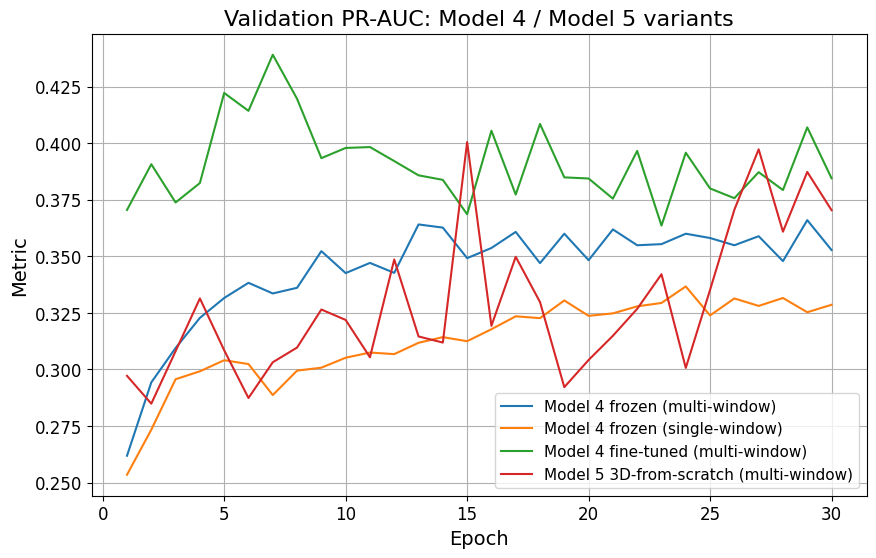

In [21]:
plt.figure(figsize=(10,6))

plt.plot(epochs_5, pr_auc_model4_mw, label="Model 4 frozen (multi-window)")
plt.plot(epochs_5, pr_auc_model4_sw, label="Model 4 frozen (single-window)")
plt.plot(epochs_5, pr_auc_model4_ft, label="Model 4 fine-tuned (multi-window)")
plt.plot(epochs_5, pr_auc_model5_mw, label="Model 5 3D-from-scratch (multi-window)")

plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title('Validation PR-AUC: Model 4 / Model 5 variants')
plt.legend()
plt.grid(True)

plt.show()

## F1-Score

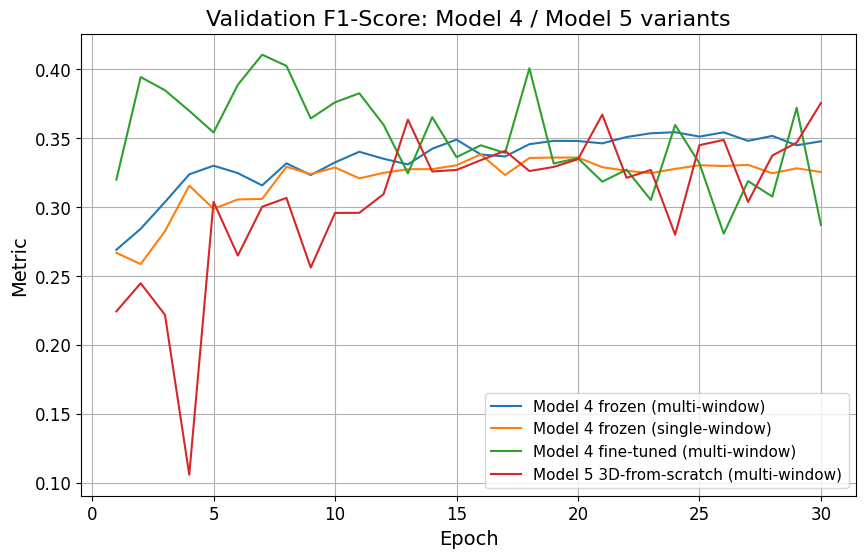

In [22]:
plt.figure(figsize=(10,6))

plt.plot(epochs_5, f1_model4_mw, label="Model 4 frozen (multi-window)")
plt.plot(epochs_5, f1_model4_sw, label="Model 4 frozen (single-window)")
plt.plot(epochs_5, f1_model4_ft, label="Model 4 fine-tuned (multi-window)")
plt.plot(epochs_5, f1_model5_mw, label="Model 5 3D-from-scratch (multi-window)")

plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title('Validation F1-Score: Model 4 / Model 5 variants')
plt.legend()
plt.grid(True)

plt.show()

## Model 4 Attention Visualisation (2.5D Slice Attention)

In [23]:
import torch
import torch.nn as nn
import torchvision
from torchvision.models import ResNet50_Weights
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    Resized, EnsureTyped
)

# --- Model 4 architecture (same definitions as train_model4_pretrained2d_fm.py) ---

class SliceEncoder(nn.Module):
    def __init__(self, freeze_backbone=True):
        super().__init__()
        backbone = torchvision.models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        self.out_dim = 2048
        if freeze_backbone:
            for p in self.features.parameters():
                p.requires_grad = False

    def forward(self, x):
        return self.features(x).flatten(1)


class AttentionPool(nn.Module):
    def __init__(self, dim=2048, hidden=256):
        super().__init__()
        self.attn = nn.Sequential(nn.Linear(dim, hidden), nn.Tanh(), nn.Linear(hidden, 1))

    def forward(self, feats):
        scores = self.attn(feats)
        weights = torch.softmax(scores, dim=1)
        pooled = (weights * feats).sum(dim=1)
        return pooled, weights.squeeze(-1)  # weights: [B, K] -- this is what we visualize


class Slice2DClassifier(nn.Module):
    def __init__(self, num_classes=18, freeze_backbone=True, pooling="attention"):
        super().__init__()
        self.encoder = SliceEncoder(freeze_backbone)
        self.pooling_type = pooling
        if pooling == "attention":
            self.pool = AttentionPool(self.encoder.out_dim, 256)
        self.classifier = nn.Linear(self.encoder.out_dim, num_classes)

    def forward(self, x):
        B, K, C, H, W = x.shape
        x = x.view(B * K, C, H, W)
        feats = self.encoder(x).view(B, K, -1)
        pooled, attn_weights = self.pool(feats)
        logits = self.classifier(pooled)
        return logits, attn_weights


# --- Multi-window preprocessing (same scheme as preprocessing_multiwindow.py) ---

WINDOWS = {"lung": (-600, 1500), "soft_tissue": (40, 400), "bone": (400, 1500)}

def _window_to_unit_range(volume, wl, ww):
    lo, hi = wl - ww / 2, wl + ww / 2
    clipped = torch.clamp(volume, lo, hi)
    return (clipped - lo) / (hi - lo)

NUM_SLICES = 32
SLICE_SIZE = 224
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def volume_to_multiwindow_slices(volume_hu):
    # volume_hu: [1, D, H, W] raw HU (single channel, pre-windowing)
    channels = [_window_to_unit_range(volume_hu[0], wl, ww) for wl, ww in WINDOWS.values()]
    multiwindow_vol = torch.stack(channels, dim=0)  # [3, D, H, W]

    depth = multiwindow_vol.shape[1]
    idxs = torch.linspace(0, depth - 1, NUM_SLICES).long()
    slices = multiwindow_vol[:, idxs, :, :]      # [3, K, H, W]
    slices = slices.permute(1, 0, 2, 3)          # [K, 3, H, W]
    slices = torch.nn.functional.interpolate(
        slices, size=(SLICE_SIZE, SLICE_SIZE), mode="bilinear", align_corners=False
    )
    slices = (slices - IMAGENET_MEAN) / IMAGENET_STD
    return slices


In [24]:
#set up device and load the fine-tuned Model 4 checkpoint
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model4 = Slice2DClassifier(num_classes=18, freeze_backbone=False, pooling="attention").to(device)
model4.load_state_dict(torch.load("../Weights_best_models/slice2d_attention_frozenFalse_k32_multiwindow_best.pth", map_location=device))
model4.eval()

# load the SAME sample volume used in the Grad-CAM section above, for direct comparison
volume_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Orientationd(keys=["image"], axcodes="RAS"),
    Spacingd(keys=["image"], pixdim=(2.0, 2.0, 2.0), mode="bilinear"),
    Resized(keys=["image"], spatial_size=(128, 128, 128)),
    EnsureTyped(keys=["image"]),
])
sample_data_m4 = volume_transforms({'image': "../dataset/CT-RATE-sample/dataset/train/train_1/train_1_a/train_1_a_1.nii.gz"})
volume_hu = sample_data_m4["image"].as_tensor() if hasattr(sample_data_m4["image"], "as_tensor") else sample_data_m4["image"]

slices_input = volume_to_multiwindow_slices(volume_hu).unsqueeze(0).to(device)  # [1, K, 3, 224, 224]

with torch.no_grad():
    logits, attn_weights = model4(slices_input)
    probs = torch.sigmoid(logits)

attn_weights_np = attn_weights[0].cpu().numpy()  # [K] -- one weight per sampled slice
print("Attention weights across", NUM_SLICES, "sampled slices:")
print(attn_weights_np)
print("\nMost-attended slice index:", attn_weights_np.argmax(), "with weight", attn_weights_np.max())


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\alvap/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:05<00:00, 19.1MB/s]


Attention weights across 32 sampled slices:
[0.0070165  0.00796511 0.01742904 0.03328692 0.03324692 0.03918873
 0.03398614 0.0368097  0.03519731 0.03468965 0.03338379 0.03338379
 0.03338379 0.03338379 0.03338379 0.03338379 0.03338379 0.03338379
 0.03338379 0.03338379 0.03338379 0.03338379 0.03338379 0.03468965
 0.03519731 0.0368097  0.0399329  0.03643185 0.03638088 0.0387859
 0.02160433 0.00736205]

Most-attended slice index: 26 with weight 0.0399329


## Attention weight per slice

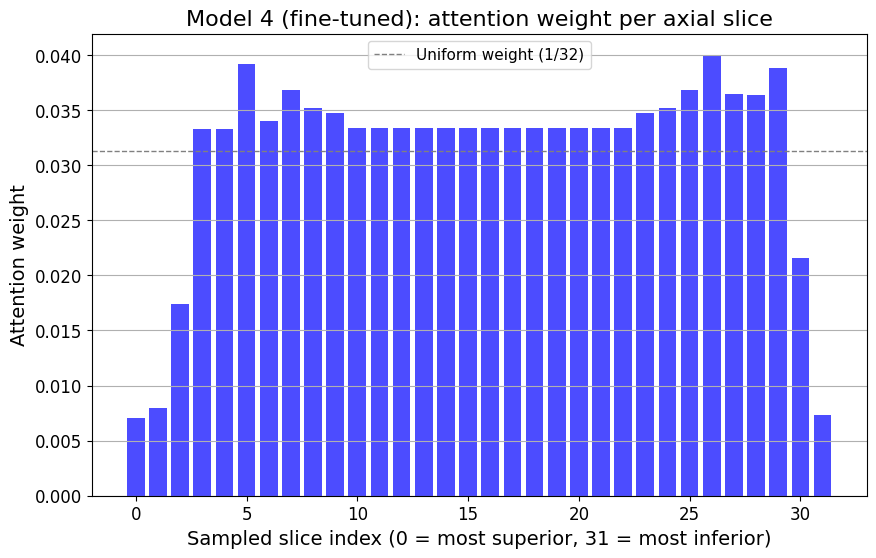

In [32]:
plt.figure(figsize=(10,6))

slice_positions = np.arange(NUM_SLICES)
plt.bar(slice_positions, attn_weights_np, color="blue", alpha=0.7)
plt.axhline(1/NUM_SLICES, color="gray", linestyle="--", linewidth=1, label=f"Uniform weight (1/{NUM_SLICES})")

plt.xlabel("Sampled slice index (0 = most superior, 31 = most inferior)")
plt.ylabel("Attention weight")
plt.title("Model 4 (fine-tuned): attention weight per axial slice")
plt.legend()
plt.grid(True, axis="y")

plt.show()

## Grad-cam

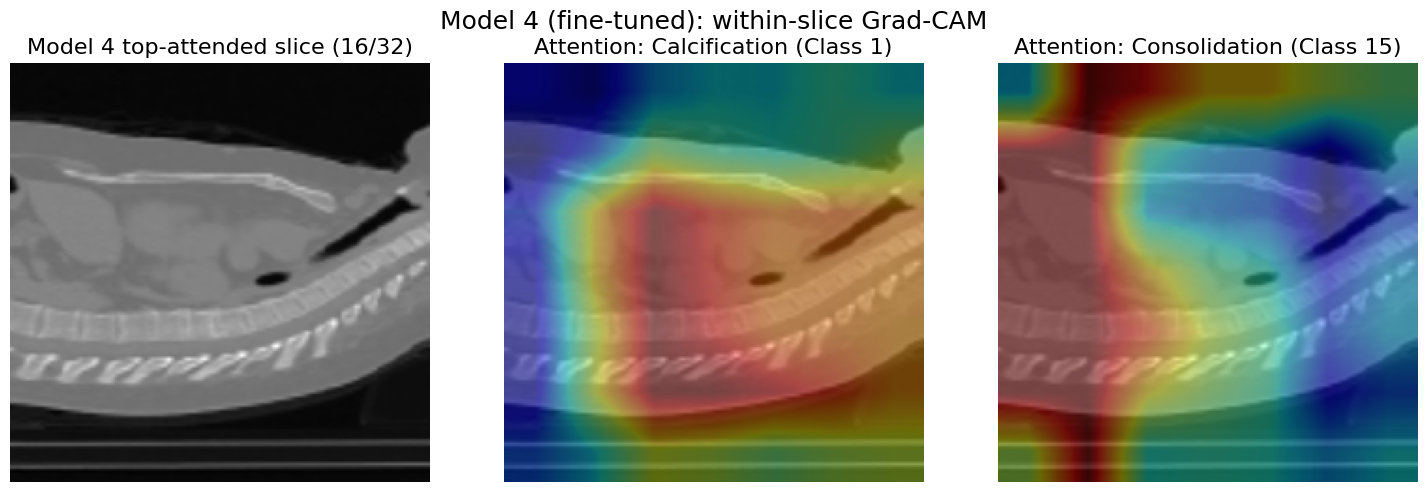

In [ ]:
import torch.nn.functional as F

# Wrap Model 4's backbone + classifier so GradCAM can target a single slice 
# (attn_weights told us WHICH slice mattered; this tells us WHERE within that slice)
class SingleSliceClassifier(nn.Module):
    def __init__(self, encoder, classifier):
        super().__init__()
        self.features = encoder.features   # same ResNet50 conv stack Model 4 uses
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = classifier

    def forward(self, x):
        feats = self.features(x)
        pooled = self.pool(feats).flatten(1)
        return self.classifier(pooled)

single_slice_model = SingleSliceClassifier(model4.encoder, model4.classifier).to(device).eval()
cam_slice = GradCAM(nn_module=single_slice_model, target_layers="features.7")  # last conv block


top_idx = NUM_SLICES // 2   
slice_tensor = slices_input[0, top_idx].unsqueeze(0)   # [1, 3, 224, 224], the actual model input
depth = volume_hu.shape[1]
original_slice_idxs = np.linspace(0, depth - 1, NUM_SLICES).astype(int)
# Rebuild a clean grayscale background at the SAME resolution as the heatmap (224x224),
# since slices_input is ImageNet-normalized and looks wrong if displayed directly
raw_hu_slice = volume_hu[0, original_slice_idxs[top_idx], :, :].unsqueeze(0).unsqueeze(0)
raw_hu_resized = F.interpolate(raw_hu_slice, size=(SLICE_SIZE, SLICE_SIZE), mode="bilinear", align_corners=False)[0, 0]
raw_np = raw_hu_resized.cpu().numpy()
display_slice_m4 = (raw_np - raw_np.min()) / (raw_np.max() - raw_np.min() + 1e-8)

# Compute the actual heatmaps (must NOT be inside a torch.no_grad() block)
target_classes_m4 = {"Calcification": 1, "Consolidation": 15}
heatmaps_m4 = {}
for class_name, class_idx in target_classes_m4.items():
    heatmap_2d = cam_slice(x=slice_tensor, class_idx=class_idx)
    heatmaps_m4[class_name] = heatmap_2d[0, 0].detach().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(display_slice_m4, cmap="gray")
axes[0].set_title(f"Model 4 top-attended slice ({top_idx}/32)")
axes[0].axis("off")

axes[1].imshow(display_slice_m4, cmap="gray")
axes[1].imshow(heatmaps_m4["Calcification"], cmap="jet", alpha=0.4)
axes[1].set_title("Attention: Calcification (Class 1)")
axes[1].axis("off")

axes[2].imshow(display_slice_m4, cmap="gray")
axes[2].imshow(heatmaps_m4["Consolidation"], cmap="jet", alpha=0.4)
axes[2].set_title("Attention: Consolidation (Class 15)")
axes[2].axis("off")

plt.suptitle("Model 4 (fine-tuned): within-slice Grad-CAM")
plt.tight_layout()
plt.show()

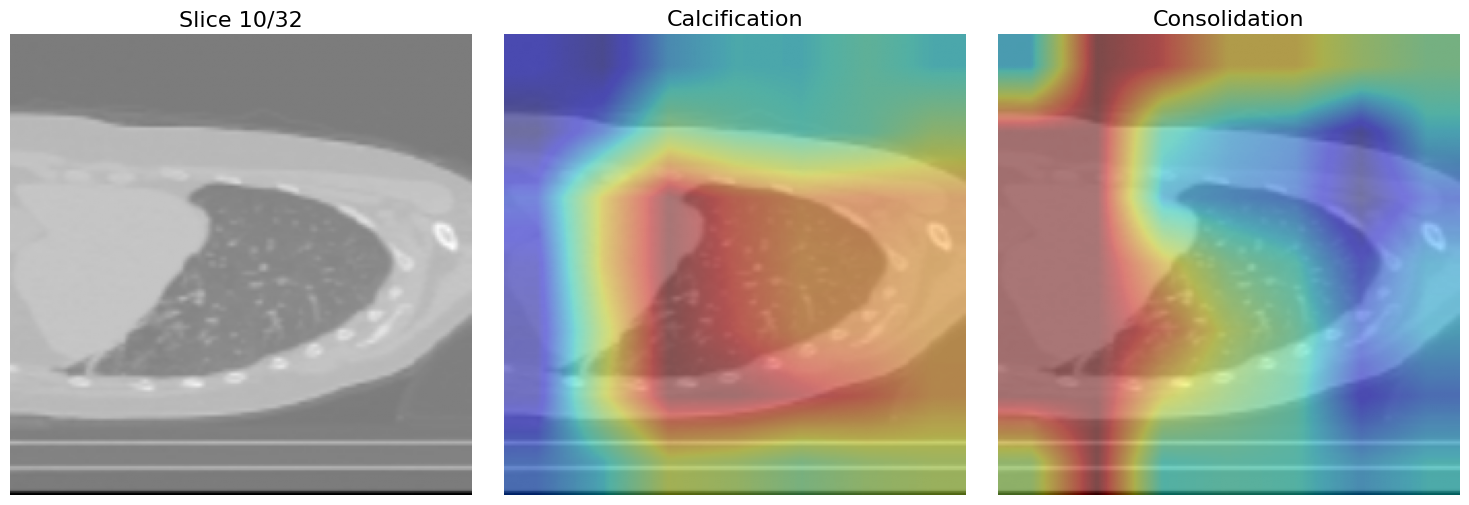

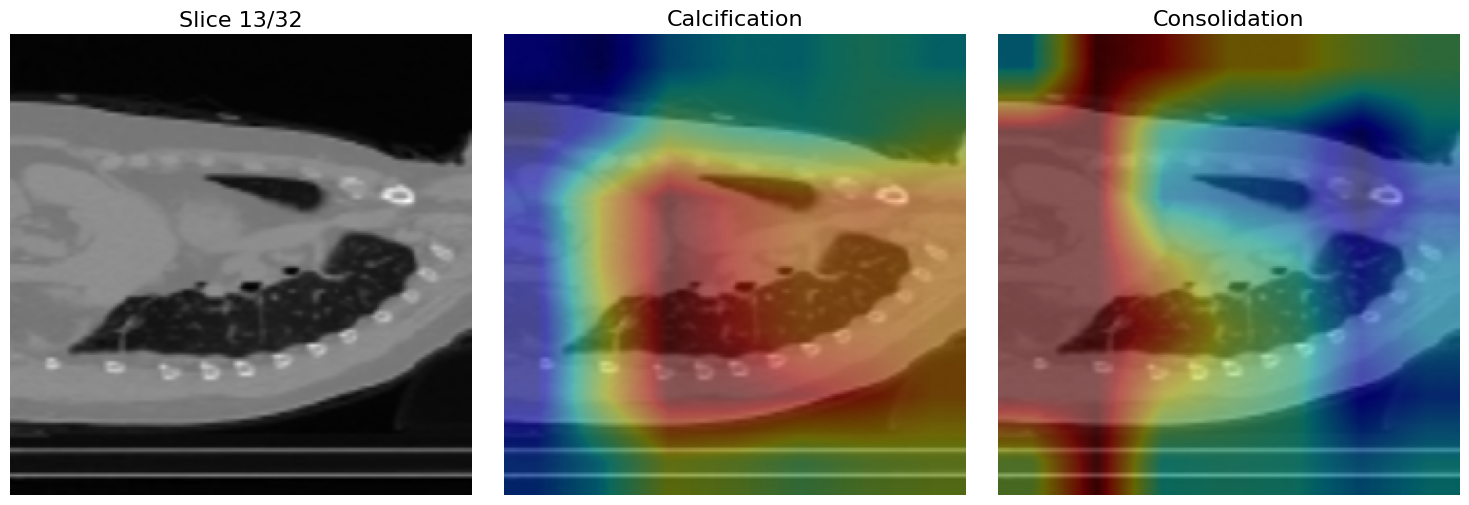

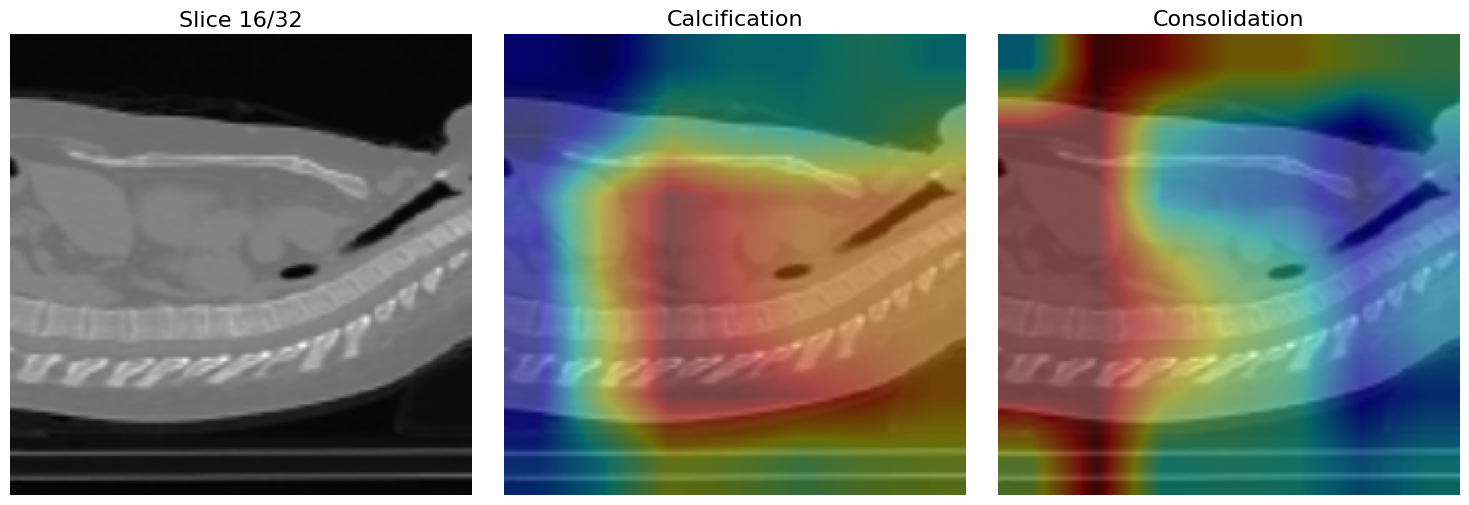

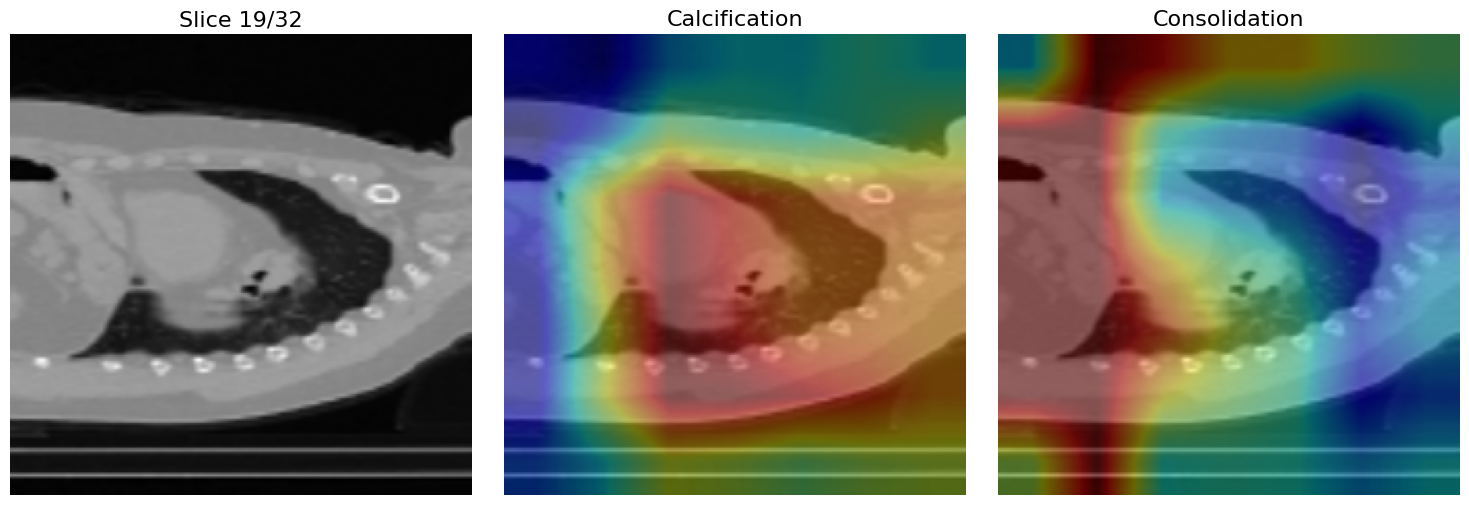

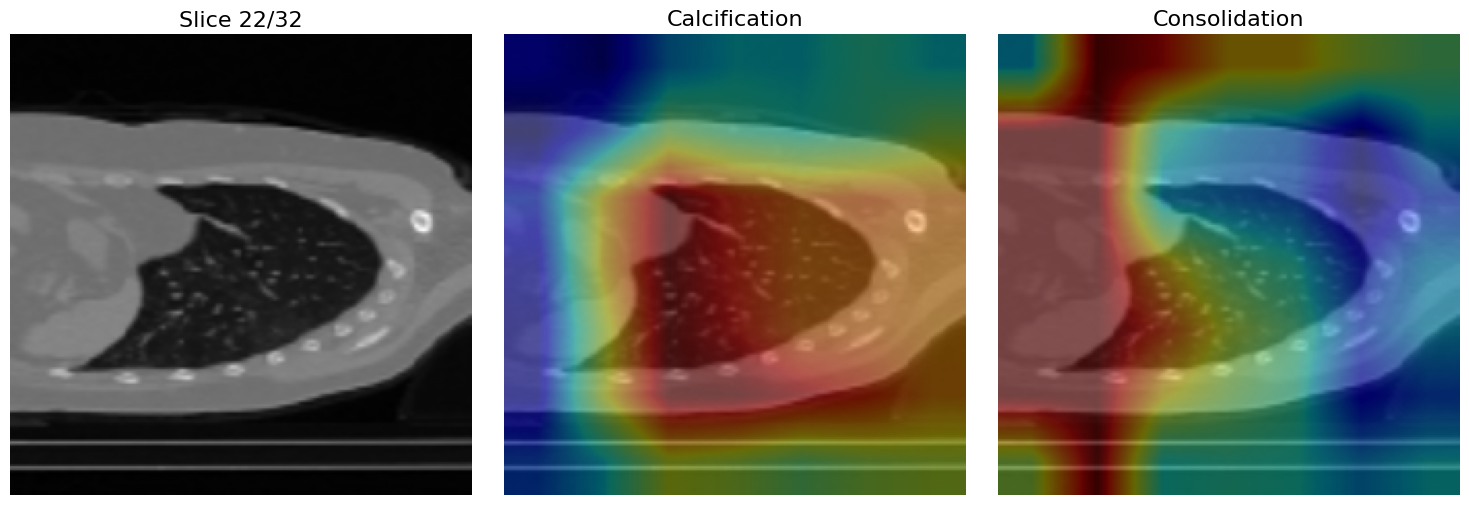

In [36]:
candidate_slices = [10, 13, 16, 19, 22]   # spread across the middle third of the 32 slices

depth = volume_hu.shape[1]
original_slice_idxs = np.linspace(0, depth - 1, NUM_SLICES).astype(int)

for top_idx in candidate_slices:
    slice_tensor = slices_input[0, top_idx].unsqueeze(0)

    raw_hu_slice = volume_hu[0, original_slice_idxs[top_idx], :, :].unsqueeze(0).unsqueeze(0)
    raw_hu_resized = F.interpolate(raw_hu_slice, size=(SLICE_SIZE, SLICE_SIZE), mode="bilinear", align_corners=False)[0, 0]
    raw_np = raw_hu_resized.cpu().numpy()
    display_slice_m4 = (raw_np - raw_np.min()) / (raw_np.max() - raw_np.min() + 1e-8)

    target_classes_m4 = {"Calcification": 1, "Consolidation": 15}
    heatmaps_m4 = {}
    for class_name, class_idx in target_classes_m4.items():
        heatmap_2d = cam_slice(x=slice_tensor, class_idx=class_idx)
        heatmaps_m4[class_name] = heatmap_2d[0, 0].detach().cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(display_slice_m4, cmap="gray")
    axes[0].set_title(f"Slice {top_idx}/32")
    axes[0].axis("off")

    axes[1].imshow(display_slice_m4, cmap="gray")
    axes[1].imshow(heatmaps_m4["Calcification"], cmap="jet", alpha=0.4)
    axes[1].set_title("Calcification")
    axes[1].axis("off")

    axes[2].imshow(display_slice_m4, cmap="gray")
    axes[2].imshow(heatmaps_m4["Consolidation"], cmap="jet", alpha=0.4)
    axes[2].set_title("Consolidation")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Fine-tuned Model 4
model4_finetuned = Slice2DClassifier(
    num_classes=18,
    freeze_backbone=False,
    pooling="attention"
).to(device)

model4_finetuned.load_state_dict(
    torch.load(
        "../Weights_best_models/slice2d_attention_frozenFalse_k32_multiwindow_best.pth",
        map_location=device
    )
)

model4_finetuned.eval()


# Frozen Model 4
model4_frozen = Slice2DClassifier(
    num_classes=18,
    freeze_backbone=True,
    pooling="attention"
).to(device)

model4_frozen.load_state_dict(
    torch.load(
        "../Weights_best_models/slice2d_attention_frozenTrue_k32_multiwindow_best.pth",
        map_location=device
    )
)

model4_frozen.eval()

Slice2DClassifier(
  (encoder): SliceEncoder(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running

In [63]:
volume_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Orientationd(keys=["image"], axcodes="RAS"),
    Spacingd(
        keys=["image"],
        pixdim=(2.0, 2.0, 2.0),
        mode="bilinear"
    ),
    Resized(
        keys=["image"],
        spatial_size=(128, 128, 128)
    ),
    EnsureTyped(keys=["image"]),
])

sample_data_m4 = volume_transforms({
    "image": "../dataset/CT-RATE-sample/dataset/train/train_1/train_1_a/train_1_a_1.nii.gz"
})

volume_hu = sample_data_m4["image"]

if hasattr(volume_hu, "as_tensor"):
    volume_hu = volume_hu.as_tensor()

# Local example scans are from the original CT-RATE train folder
# and retain the +8192 intensity offset
volume_hu = volume_hu - 8192

slices_input = (
    volume_to_multiwindow_slices(volume_hu)
    .unsqueeze(0)
    .to(device)
)

print("Input shape:", slices_input.shape)

Input shape: torch.Size([1, 32, 3, 224, 224])


In [67]:
with torch.no_grad():
    logits_frozen, attn_frozen = model4_frozen(slices_input)
    logits_finetuned, attn_finetuned = model4_finetuned(slices_input)

attn_frozen_np = attn_frozen[0].cpu().numpy()
attn_finetuned_np = attn_finetuned[0].cpu().numpy()

print("Frozen model:")
print("Most-attended slice:", attn_frozen_np.argmax())
print("Attention weight:", attn_frozen_np.max())

print("\nFine-tuned model:")
print("Most-attended slice:", attn_finetuned_np.argmax())
print("Attention weight:", attn_finetuned_np.max())

Frozen model:
Most-attended slice: 24
Attention weight: 0.58259666

Fine-tuned model:
Most-attended slice: 13
Attention weight: 0.2898305


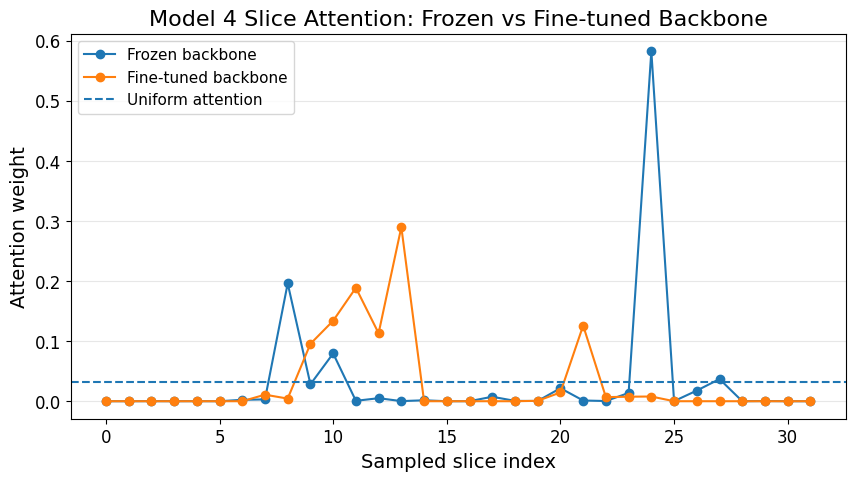

In [69]:
slice_indices = np.arange(NUM_SLICES)

plt.figure(figsize=(10, 5))

plt.plot(
    slice_indices,
    attn_frozen_np,
    marker="o",
    label="Frozen backbone"
)

plt.plot(
    slice_indices,
    attn_finetuned_np,
    marker="o",
    label="Fine-tuned backbone"
)

plt.axhline(
    1 / NUM_SLICES,
    linestyle="--",
    label="Uniform attention"
)

plt.xlabel("Sampled slice index")
plt.ylabel("Attention weight")
plt.title("Model 4 Slice Attention: Frozen vs Fine-tuned Backbone")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

In [65]:
slice_differences = []

for i in range(NUM_SLICES - 1):
    diff = torch.mean(
        torch.abs(slices_input[0, i + 1] - slices_input[0, i])
    ).item()

    slice_differences.append(diff)

for i, diff in enumerate(slice_differences):
    print(f"Slice {i:2d} -> {i+1:2d}: {diff:.6f}")

Slice  0 ->  1: 0.159044
Slice  1 ->  2: 0.211018
Slice  2 ->  3: 0.249115
Slice  3 ->  4: 0.221586
Slice  4 ->  5: 0.251505
Slice  5 ->  6: 0.283906
Slice  6 ->  7: 0.338747
Slice  7 ->  8: 0.321868
Slice  8 ->  9: 0.266960
Slice  9 -> 10: 0.229423
Slice 10 -> 11: 0.227675
Slice 11 -> 12: 0.206228
Slice 12 -> 13: 0.260275
Slice 13 -> 14: 0.275909
Slice 14 -> 15: 0.327228
Slice 15 -> 16: 0.257877
Slice 16 -> 17: 0.250122
Slice 17 -> 18: 0.299783
Slice 18 -> 19: 0.290552
Slice 19 -> 20: 0.219141
Slice 20 -> 21: 0.240356
Slice 21 -> 22: 0.237828
Slice 22 -> 23: 0.256097
Slice 23 -> 24: 0.286392
Slice 24 -> 25: 0.354643
Slice 25 -> 26: 0.312171
Slice 26 -> 27: 0.261411
Slice 27 -> 28: 0.223744
Slice 28 -> 29: 0.233588
Slice 29 -> 30: 0.219957
Slice 30 -> 31: 0.261069


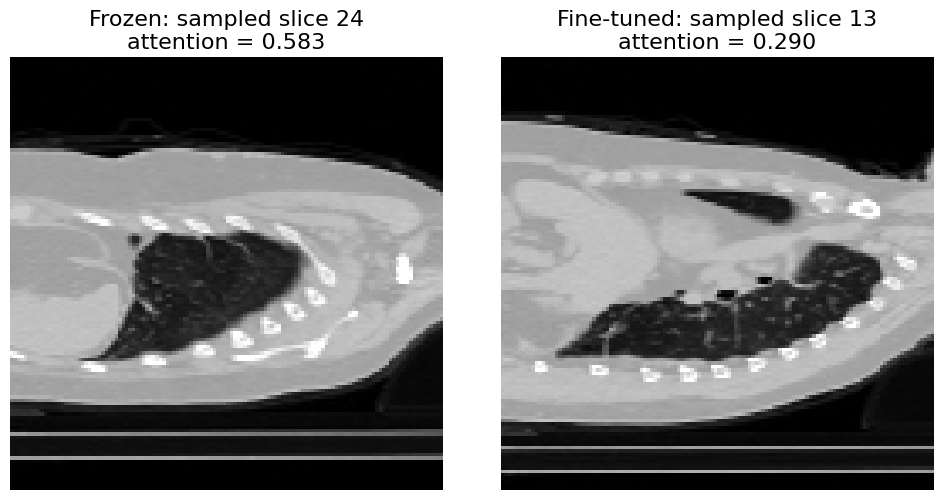

In [70]:
# Convert sampled slice numbers back to indices in the resized 128-slice volume
sampled_indices = torch.linspace(
    0,
    volume_hu.shape[1] - 1,
    NUM_SLICES
).long()

frozen_top = int(attn_frozen_np.argmax())       # 24
finetuned_top = int(attn_finetuned_np.argmax()) # 13

frozen_volume_idx = sampled_indices[frozen_top].item()
finetuned_volume_idx = sampled_indices[finetuned_top].item()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(
    volume_hu[0, frozen_volume_idx].cpu(),
    cmap="gray",
    vmin=-1000,
    vmax=400
)
axes[0].set_title(
    f"Frozen: sampled slice {frozen_top}\n"
    f"attention = {attn_frozen_np[frozen_top]:.3f}"
)
axes[0].axis("off")

axes[1].imshow(
    volume_hu[0, finetuned_volume_idx].cpu(),
    cmap="gray",
    vmin=-1000,
    vmax=400
)
axes[1].set_title(
    f"Fine-tuned: sampled slice {finetuned_top}\n"
    f"attention = {attn_finetuned_np[finetuned_top]:.3f}"
)
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [72]:
LABEL_COLS = [
    "Medical material",
    "Arterial wall calcification",
    "Cardiomegaly",
    "Pericardial effusion",
    "Coronary artery wall calcification",
    "Hiatal hernia",
    "Lymphadenopathy",
    "Emphysema",
    "Atelectasis",
    "Lung nodule",
    "Lung opacity",
    "Pulmonary fibrotic sequela",
    "Pleural effusion",
    "Mosaic attenuation pattern",
    "Peribronchial thickening",
    "Consolidation",
    "Bronchiectasis",
    "Interlobular septal thickening"
]

In [73]:
probs_frozen = torch.sigmoid(logits_frozen)[0].cpu().numpy()
probs_finetuned = torch.sigmoid(logits_finetuned)[0].cpu().numpy()

for i, label in enumerate(LABEL_COLS):
    print(
        f"{i:2d} {label:35s} "
        f"Frozen: {probs_frozen[i]:.3f}   "
        f"Fine-tuned: {probs_finetuned[i]:.3f}"
    )

 0 Medical material                    Frozen: 0.548   Fine-tuned: 0.305
 1 Arterial wall calcification         Frozen: 0.644   Fine-tuned: 0.465
 2 Cardiomegaly                        Frozen: 0.492   Fine-tuned: 0.163
 3 Pericardial effusion                Frozen: 0.558   Fine-tuned: 0.554
 4 Coronary artery wall calcification  Frozen: 0.668   Fine-tuned: 0.422
 5 Hiatal hernia                       Frozen: 0.586   Fine-tuned: 0.339
 6 Lymphadenopathy                     Frozen: 0.511   Fine-tuned: 0.573
 7 Emphysema                           Frozen: 0.483   Fine-tuned: 0.482
 8 Atelectasis                         Frozen: 0.636   Fine-tuned: 0.724
 9 Lung nodule                         Frozen: 0.479   Fine-tuned: 0.528
10 Lung opacity                        Frozen: 0.604   Fine-tuned: 0.661
11 Pulmonary fibrotic sequela          Frozen: 0.493   Fine-tuned: 0.330
12 Pleural effusion                    Frozen: 0.462   Fine-tuned: 0.321
13 Mosaic attenuation pattern          Frozen: 0.58

In [74]:
label_path = "../dataset/CT-RATE-sample/dataset/multi_abnormality_labels/train_predicted_labels.csv"

labels_df = pd.read_csv(label_path)

sample_name = "train_1_a_1.nii.gz"

sample_row = labels_df[
    labels_df["VolumeName"] == sample_name
]

print(sample_row[["VolumeName"] + LABEL_COLS].T)

                                                     0
VolumeName                          train_1_a_1.nii.gz
Medical material                                     0
Arterial wall calcification                          1
Cardiomegaly                                         0
Pericardial effusion                                 0
Coronary artery wall calcification                   0
Hiatal hernia                                        0
Lymphadenopathy                                      0
Emphysema                                            0
Atelectasis                                          1
Lung nodule                                          0
Lung opacity                                         1
Pulmonary fibrotic sequela                           0
Pleural effusion                                     0
Mosaic attenuation pattern                           0
Peribronchial thickening                             1
Consolidation                                        1
Bronchiect

In [75]:
class_idx = 15
class_name = "Consolidation"

print("Class:", class_name)
print("Frozen probability:", probs_frozen[class_idx])
print("Fine-tuned probability:", probs_finetuned[class_idx])

Class: Consolidation
Frozen probability: 0.60446274
Fine-tuned probability: 0.63383687


In [76]:
from monai.visualize import GradCAM

class SingleSliceClassifier(nn.Module):
    def __init__(self, encoder, classifier):
        super().__init__()
        self.features = encoder.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = classifier

    def forward(self, x):
        feats = self.features(x)
        pooled = self.pool(feats).flatten(1)
        return self.classifier(pooled)


# Frozen backbone version
single_slice_frozen = SingleSliceClassifier(
    model4_frozen.encoder,
    model4_frozen.classifier
).to(device).eval()


# Fine-tuned backbone version
single_slice_finetuned = SingleSliceClassifier(
    model4_finetuned.encoder,
    model4_finetuned.classifier
).to(device).eval()


# Grad-CAM objects
cam_frozen = GradCAM(
    nn_module=single_slice_frozen,
    target_layers="features.7"
)

cam_finetuned = GradCAM(
    nn_module=single_slice_finetuned,
    target_layers="features.7"
)

print("Grad-CAM models ready.")

Grad-CAM models ready.


C:\Users\alvap\AppData\Local\Temp\ipykernel_9244\2314465997.py:198: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


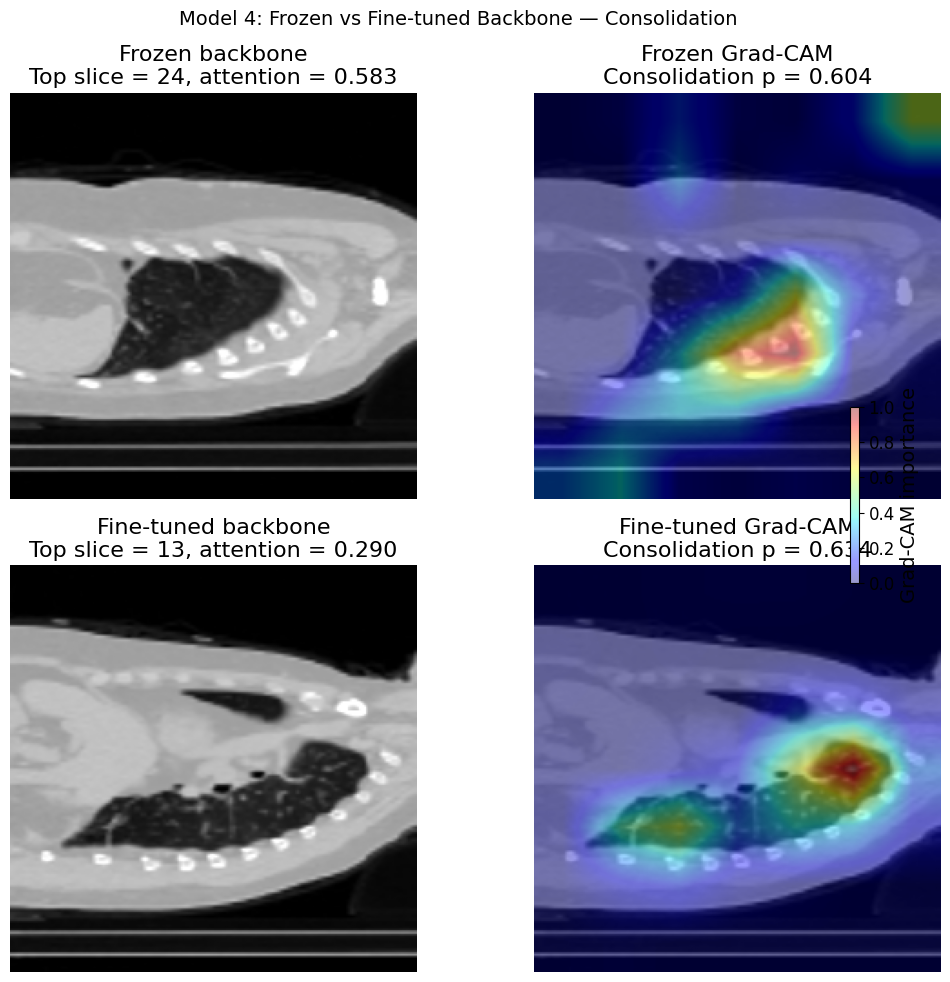

In [77]:
# Corrected Grad-CAM comparison:
# Frozen vs fine-tuned Model 4 for Consolidation

class_idx = 15
class_name = "Consolidation"


# ---------------------------------------------------------
# Re-create Grad-CAM objects WITHOUT MONAI's default
# inverted post-processing
# ---------------------------------------------------------

cam_frozen_correct = GradCAM(
    nn_module=single_slice_frozen,
    target_layers="features.7",
    postprocessing=lambda x: x
)

cam_finetuned_correct = GradCAM(
    nn_module=single_slice_finetuned,
    target_layers="features.7",
    postprocessing=lambda x: x
)


def generate_corrected_gradcam(
    cam_object,
    model,
    sampled_slice_idx,
    class_idx
):
    """
    Generate Grad-CAM for one of the 32 sampled slices.
    """

    # Model input for this slice
    slice_tensor = (
        slices_input[0, sampled_slice_idx]
        .unsqueeze(0)
        .clone()
        .detach()
        .requires_grad_(True)
    )

    model.zero_grad(set_to_none=True)

    # Raw Grad-CAM
    heatmap = cam_object(
        x=slice_tensor,
        class_idx=class_idx
    )[0, 0]

    # Standard Grad-CAM convention:
    # keep positive evidence and scale 0 -> 1
    heatmap = torch.relu(heatmap)

    heatmap = heatmap - heatmap.min()
    heatmap = heatmap / (heatmap.max() + 1e-8)

    heatmap = heatmap.detach().cpu().numpy()

    # Map sampled slice back to its location
    # in the 128-slice CT volume
    volume_idx = int(sampled_indices[sampled_slice_idx])

    raw_slice = (
        volume_hu[0, volume_idx]
        .unsqueeze(0)
        .unsqueeze(0)
        .float()
    )

    # Resize CT slice to 224x224 so it exactly matches Grad-CAM
    display_slice = F.interpolate(
        raw_slice,
        size=(SLICE_SIZE, SLICE_SIZE),
        mode="bilinear",
        align_corners=False
    )[0, 0].cpu().numpy()

    return display_slice, heatmap


# ---------------------------------------------------------
# Each model's most-attended slice
# ---------------------------------------------------------

frozen_slice = int(attn_frozen_np.argmax())
finetuned_slice = int(attn_finetuned_np.argmax())

frozen_img, frozen_cam = generate_corrected_gradcam(
    cam_frozen_correct,
    single_slice_frozen,
    frozen_slice,
    class_idx
)

finetuned_img, finetuned_cam = generate_corrected_gradcam(
    cam_finetuned_correct,
    single_slice_finetuned,
    finetuned_slice,
    class_idx
)


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(10, 10))


# Frozen - original
axes[0, 0].imshow(
    frozen_img,
    cmap="gray",
    vmin=-1000,
    vmax=400
)
axes[0, 0].set_title(
    f"Frozen backbone\n"
    f"Top slice = {frozen_slice}, "
    f"attention = {attn_frozen_np[frozen_slice]:.3f}"
)
axes[0, 0].axis("off")


# Frozen - Grad-CAM
axes[0, 1].imshow(
    frozen_img,
    cmap="gray",
    vmin=-1000,
    vmax=400
)
axes[0, 1].imshow(
    frozen_cam,
    cmap="jet",
    alpha=0.4,
    vmin=0,
    vmax=1
)
axes[0, 1].set_title(
    f"Frozen Grad-CAM\n"
    f"{class_name} p = {probs_frozen[class_idx]:.3f}"
)
axes[0, 1].axis("off")


# Fine-tuned - original
axes[1, 0].imshow(
    finetuned_img,
    cmap="gray",
    vmin=-1000,
    vmax=400
)
axes[1, 0].set_title(
    f"Fine-tuned backbone\n"
    f"Top slice = {finetuned_slice}, "
    f"attention = {attn_finetuned_np[finetuned_slice]:.3f}"
)
axes[1, 0].axis("off")


# Fine-tuned - Grad-CAM
axes[1, 1].imshow(
    finetuned_img,
    cmap="gray",
    vmin=-1000,
    vmax=400
)
im = axes[1, 1].imshow(
    finetuned_cam,
    cmap="jet",
    alpha=0.4,
    vmin=0,
    vmax=1
)
axes[1, 1].set_title(
    f"Fine-tuned Grad-CAM\n"
    f"{class_name} p = {probs_finetuned[class_idx]:.3f}"
)
axes[1, 1].axis("off")


fig.colorbar(
    im,
    ax=axes[:, 1],
    fraction=0.025,
    pad=0.02,
    label="Grad-CAM importance"
)

plt.suptitle(
    "Model 4: Frozen vs Fine-tuned Backbone — Consolidation",
    fontsize=14
)

plt.tight_layout()
plt.show()

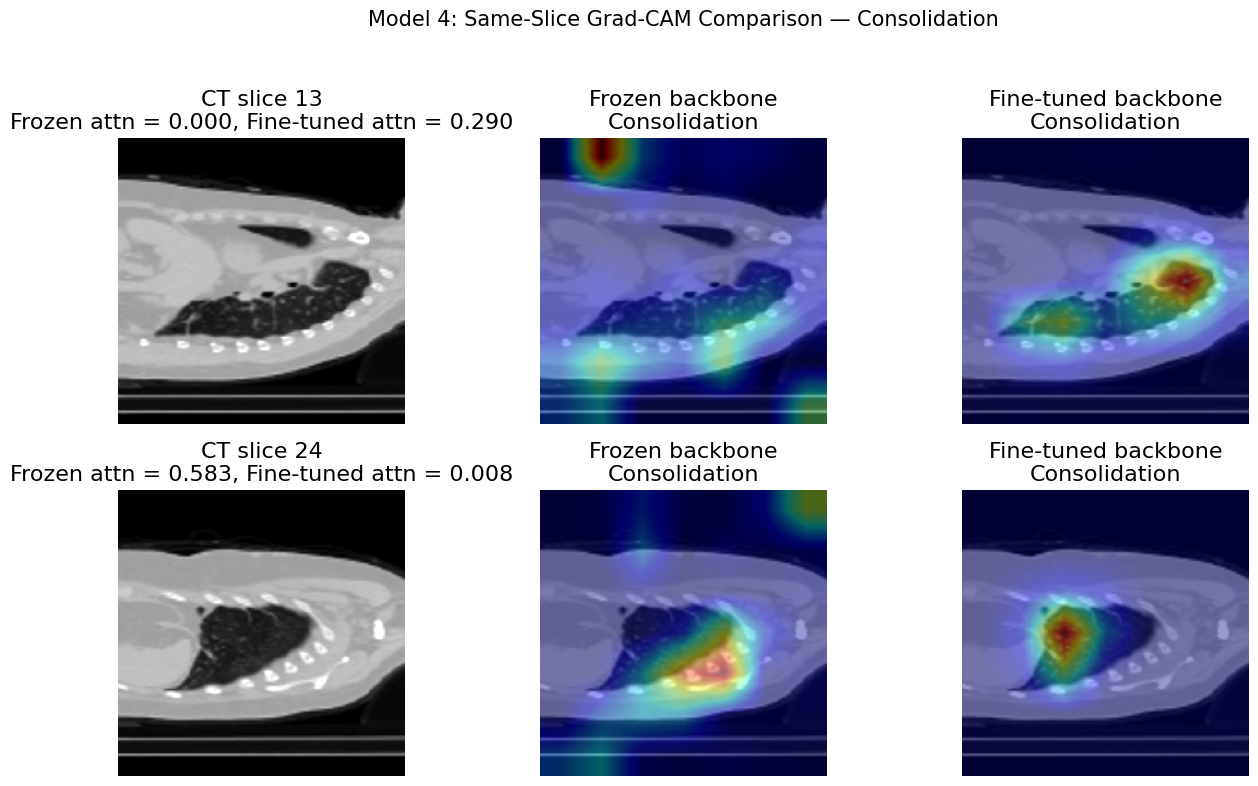

In [78]:
# ---------------------------------------------------------
# Same-slice Grad-CAM comparison
# Compare BOTH models on BOTH important slices
# ---------------------------------------------------------

compare_slices = [
    int(finetuned_slice),   # 13
    int(frozen_slice)       # 24
]

fig, axes = plt.subplots(
    len(compare_slices),
    3,
    figsize=(13, 8)
)

for row, slice_idx in enumerate(compare_slices):

    # Generate Grad-CAM from BOTH models on the SAME slice
    display_img, frozen_cam_same = generate_corrected_gradcam(
        cam_frozen_correct,
        single_slice_frozen,
        slice_idx,
        class_idx
    )

    _, finetuned_cam_same = generate_corrected_gradcam(
        cam_finetuned_correct,
        single_slice_finetuned,
        slice_idx,
        class_idx
    )

    # -----------------------
    # Original CT
    # -----------------------
    axes[row, 0].imshow(
        display_img,
        cmap="gray",
        vmin=-1000,
        vmax=400
    )

    axes[row, 0].set_title(
        f"CT slice {slice_idx}\n"
        f"Frozen attn = {attn_frozen_np[slice_idx]:.3f}, "
        f"Fine-tuned attn = {attn_finetuned_np[slice_idx]:.3f}"
    )

    axes[row, 0].axis("off")


    # -----------------------
    # Frozen Grad-CAM
    # -----------------------
    axes[row, 1].imshow(
        display_img,
        cmap="gray",
        vmin=-1000,
        vmax=400
    )

    axes[row, 1].imshow(
        frozen_cam_same,
        cmap="jet",
        alpha=0.4,
        vmin=0,
        vmax=1
    )

    axes[row, 1].set_title(
        f"Frozen backbone\n"
        f"Consolidation"
    )

    axes[row, 1].axis("off")


    # -----------------------
    # Fine-tuned Grad-CAM
    # -----------------------
    axes[row, 2].imshow(
        display_img,
        cmap="gray",
        vmin=-1000,
        vmax=400
    )

    im = axes[row, 2].imshow(
        finetuned_cam_same,
        cmap="jet",
        alpha=0.4,
        vmin=0,
        vmax=1
    )

    axes[row, 2].set_title(
        f"Fine-tuned backbone\n"
        f"Consolidation"
    )

    axes[row, 2].axis("off")


plt.suptitle(
    "Model 4: Same-Slice Grad-CAM Comparison — Consolidation",
    fontsize=15
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Frozen top slices:
  slice 24  attention = 0.5826
  slice  8  attention = 0.1961
  slice 10  attention = 0.0795
  slice 27  attention = 0.0369
  slice  9  attention = 0.0282

Fine-tuned top slices:
  slice 13  attention = 0.2898
  slice 11  attention = 0.1888
  slice 10  attention = 0.1339
  slice 21  attention = 0.1259
  slice 12  attention = 0.1131


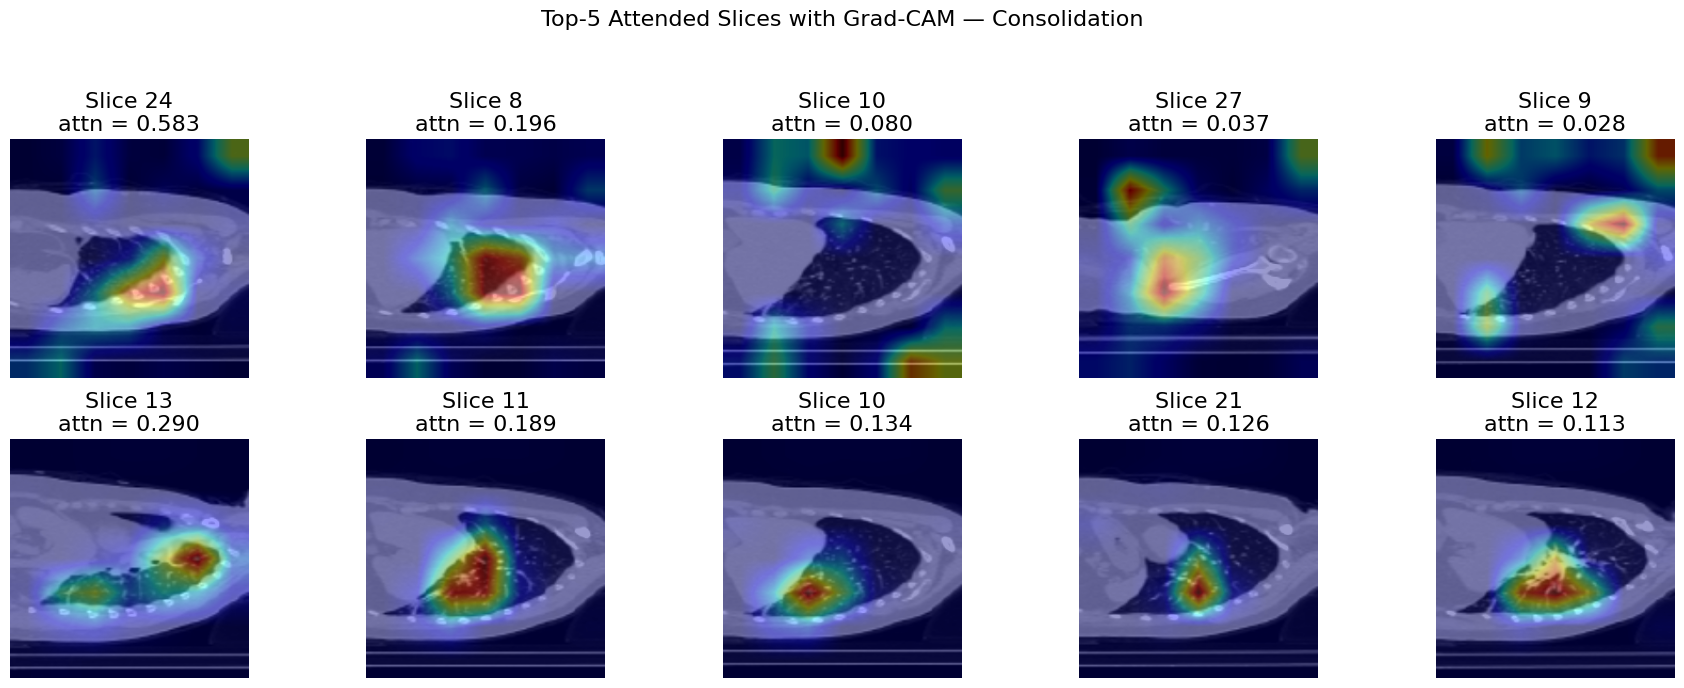

In [79]:
# ---------------------------------------------------------
# Top-5 attended slices + Grad-CAM for each model
# Consolidation
# ---------------------------------------------------------

TOP_K = 5

top_frozen = np.argsort(attn_frozen_np)[-TOP_K:][::-1]
top_finetuned = np.argsort(attn_finetuned_np)[-TOP_K:][::-1]

print("Frozen top slices:")
for s in top_frozen:
    print(f"  slice {s:2d}  attention = {attn_frozen_np[s]:.4f}")

print("\nFine-tuned top slices:")
for s in top_finetuned:
    print(f"  slice {s:2d}  attention = {attn_finetuned_np[s]:.4f}")


fig, axes = plt.subplots(
    2,
    TOP_K,
    figsize=(18, 7)
)

# ---------------------------------------------------------
# Frozen model
# ---------------------------------------------------------

for col, slice_idx in enumerate(top_frozen):

    img, cam = generate_corrected_gradcam(
        cam_frozen_correct,
        single_slice_frozen,
        int(slice_idx),
        class_idx
    )

    axes[0, col].imshow(
        img,
        cmap="gray",
        vmin=-1000,
        vmax=400
    )

    axes[0, col].imshow(
        cam,
        cmap="jet",
        alpha=0.4,
        vmin=0,
        vmax=1
    )

    axes[0, col].set_title(
        f"Slice {slice_idx}\n"
        f"attn = {attn_frozen_np[slice_idx]:.3f}"
    )

    axes[0, col].axis("off")


# ---------------------------------------------------------
# Fine-tuned model
# ---------------------------------------------------------

for col, slice_idx in enumerate(top_finetuned):

    img, cam = generate_corrected_gradcam(
        cam_finetuned_correct,
        single_slice_finetuned,
        int(slice_idx),
        class_idx
    )

    axes[1, col].imshow(
        img,
        cmap="gray",
        vmin=-1000,
        vmax=400
    )

    axes[1, col].imshow(
        cam,
        cmap="jet",
        alpha=0.4,
        vmin=0,
        vmax=1
    )

    axes[1, col].set_title(
        f"Slice {slice_idx}\n"
        f"attn = {attn_finetuned_np[slice_idx]:.3f}"
    )

    axes[1, col].axis("off")


# Row labels
axes[0, 0].set_ylabel(
    "Frozen",
    fontsize=14
)

axes[1, 0].set_ylabel(
    "Fine-tuned",
    fontsize=14
)

plt.suptitle(
    f"Top-{TOP_K} Attended Slices with Grad-CAM — Consolidation",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

FROZEN
Actual logit:        0.424095
Reconstructed logit: 0.424095

FINE-TUNED
Actual logit:        0.548713
Reconstructed logit: 0.548712

Top frozen slices contributing to Consolidation:
Slice 24: attention=0.5826, slice score=0.6545, contribution=0.3813
Slice  8: attention=0.1961, slice score=0.2990, contribution=0.0586
Slice 26: attention=0.0177, slice score=0.8145, contribution=0.0144
Slice 27: attention=0.0369, slice score=0.3719, contribution=0.0137
Slice 20: attention=0.0217, slice score=0.1109, contribution=0.0024

Top fine-tuned slices contributing to Consolidation:
Slice 13: attention=0.2898, slice score=1.5480, contribution=0.4487
Slice 11: attention=0.1888, slice score=0.8498, contribution=0.1605
Slice 10: attention=0.1339, slice score=0.1662, contribution=0.0223
Slice  9: attention=0.0955, slice score=0.1598, contribution=0.0153
Slice 12: attention=0.1131, slice score=0.1265, contribution=0.0143


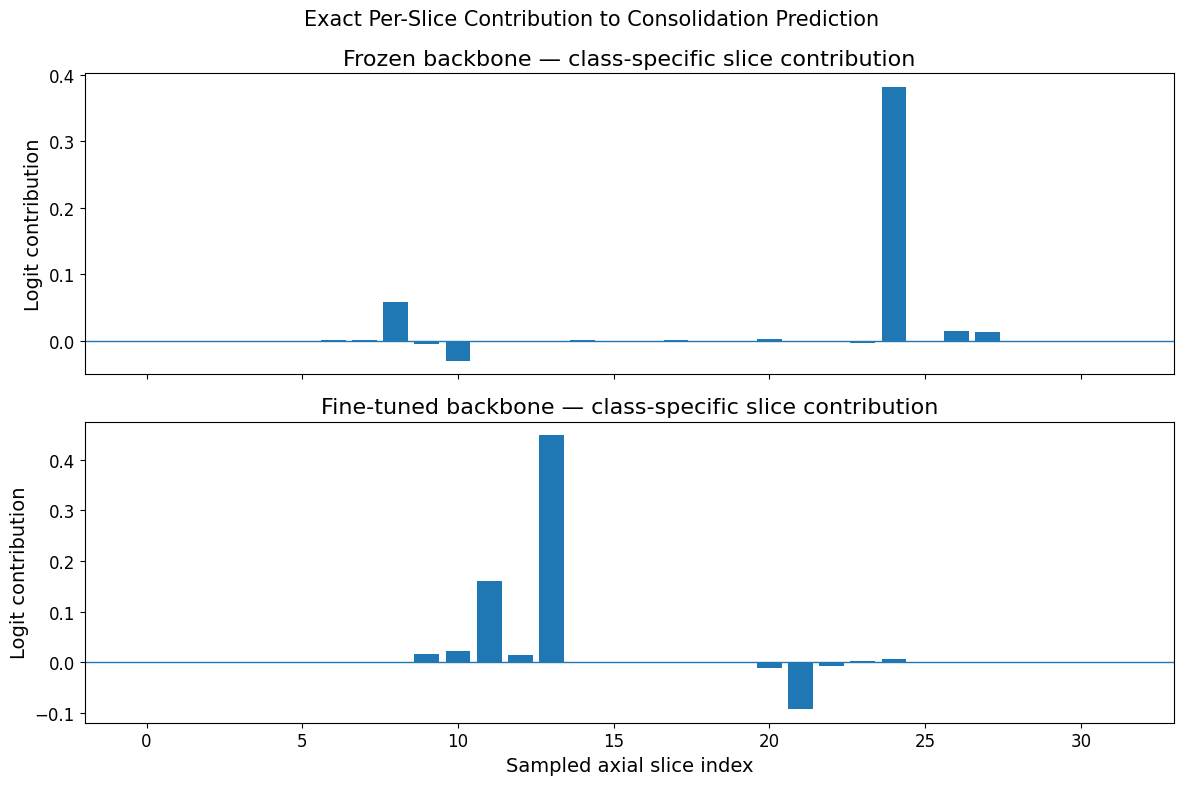

In [80]:
# ---------------------------------------------------------
# Exact class-specific slice contributions
# Model 4: Frozen vs Fine-tuned
# Class = Consolidation
# ---------------------------------------------------------

class_idx = 15
class_name = "Consolidation"


def get_slice_contributions(model, slices_input, class_idx):
    """
    Calculate the exact contribution of each slice to a class logit.

    For this architecture:

        pooled = sum(attention_s * feature_s)

        logit_c = W_c @ pooled + bias_c

    therefore:

        contribution_s = attention_s * (W_c @ feature_s)
    """

    model.eval()

    with torch.no_grad():

        B, K, C, H, W = slices_input.shape

        # -----------------------------
        # Extract slice features
        # -----------------------------
        x = slices_input.view(B * K, C, H, W)

        feats = model.encoder(x)
        feats = feats.view(B, K, -1)   # [B, K, 2048]


        # -----------------------------
        # Attention weights
        # -----------------------------
        _, attention = model.pool(feats)   # [B, K]


        # -----------------------------
        # Class-specific score of each
        # individual slice feature
        # -----------------------------
        class_weight = model.classifier.weight[class_idx]

        slice_class_scores = torch.einsum(
            "bkd,d->bk",
            feats,
            class_weight
        )


        # -----------------------------
        # Exact contribution after
        # attention weighting
        # -----------------------------
        contributions = (
            attention * slice_class_scores
        )


        # Reconstruct full class logit
        bias = model.classifier.bias[class_idx]

        reconstructed_logit = (
            contributions.sum(dim=1) + bias
        )


        # Actual model logit
        actual_logits, _ = model(slices_input)
        actual_logit = actual_logits[:, class_idx]


    return (
        attention[0].cpu().numpy(),
        slice_class_scores[0].cpu().numpy(),
        contributions[0].cpu().numpy(),
        reconstructed_logit.item(),
        actual_logit.item()
    )


# ---------------------------------------------------------
# Frozen model
# ---------------------------------------------------------

(
    frozen_attention,
    frozen_slice_scores,
    frozen_contributions,
    frozen_reconstructed,
    frozen_actual
) = get_slice_contributions(
    model4_frozen,
    slices_input,
    class_idx
)


# ---------------------------------------------------------
# Fine-tuned model
# ---------------------------------------------------------

(
    finetuned_attention,
    finetuned_slice_scores,
    finetuned_contributions,
    finetuned_reconstructed,
    finetuned_actual
) = get_slice_contributions(
    model4_finetuned,
    slices_input,
    class_idx
)


# ---------------------------------------------------------
# Sanity check
# ---------------------------------------------------------

print("FROZEN")
print(
    f"Actual logit:        {frozen_actual:.6f}"
)
print(
    f"Reconstructed logit: {frozen_reconstructed:.6f}"
)

print("\nFINE-TUNED")
print(
    f"Actual logit:        {finetuned_actual:.6f}"
)
print(
    f"Reconstructed logit: {finetuned_reconstructed:.6f}"
)


# ---------------------------------------------------------
# Show slices with strongest POSITIVE contribution
# to Consolidation
# ---------------------------------------------------------

top_frozen_contrib = np.argsort(
    frozen_contributions
)[::-1][:5]

top_finetuned_contrib = np.argsort(
    finetuned_contributions
)[::-1][:5]


print("\nTop frozen slices contributing to Consolidation:")

for s in top_frozen_contrib:
    print(
        f"Slice {s:2d}: "
        f"attention={frozen_attention[s]:.4f}, "
        f"slice score={frozen_slice_scores[s]:.4f}, "
        f"contribution={frozen_contributions[s]:.4f}"
    )


print("\nTop fine-tuned slices contributing to Consolidation:")

for s in top_finetuned_contrib:
    print(
        f"Slice {s:2d}: "
        f"attention={finetuned_attention[s]:.4f}, "
        f"slice score={finetuned_slice_scores[s]:.4f}, "
        f"contribution={finetuned_contributions[s]:.4f}"
    )


# ---------------------------------------------------------
# Plot exact contribution by slice
# ---------------------------------------------------------

slice_indices = np.arange(NUM_SLICES)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 8),
    sharex=True
)


axes[0].bar(
    slice_indices,
    frozen_contributions
)
axes[0].axhline(
    0,
    linewidth=1
)
axes[0].set_ylabel("Logit contribution")
axes[0].set_title(
    "Frozen backbone — class-specific slice contribution"
)


axes[1].bar(
    slice_indices,
    finetuned_contributions
)
axes[1].axhline(
    0,
    linewidth=1
)
axes[1].set_xlabel(
    "Sampled axial slice index"
)
axes[1].set_ylabel(
    "Logit contribution"
)
axes[1].set_title(
    "Fine-tuned backbone — class-specific slice contribution"
)


plt.suptitle(
    "Exact Per-Slice Contribution to Consolidation Prediction",
    fontsize=15
)

plt.tight_layout()
plt.show()

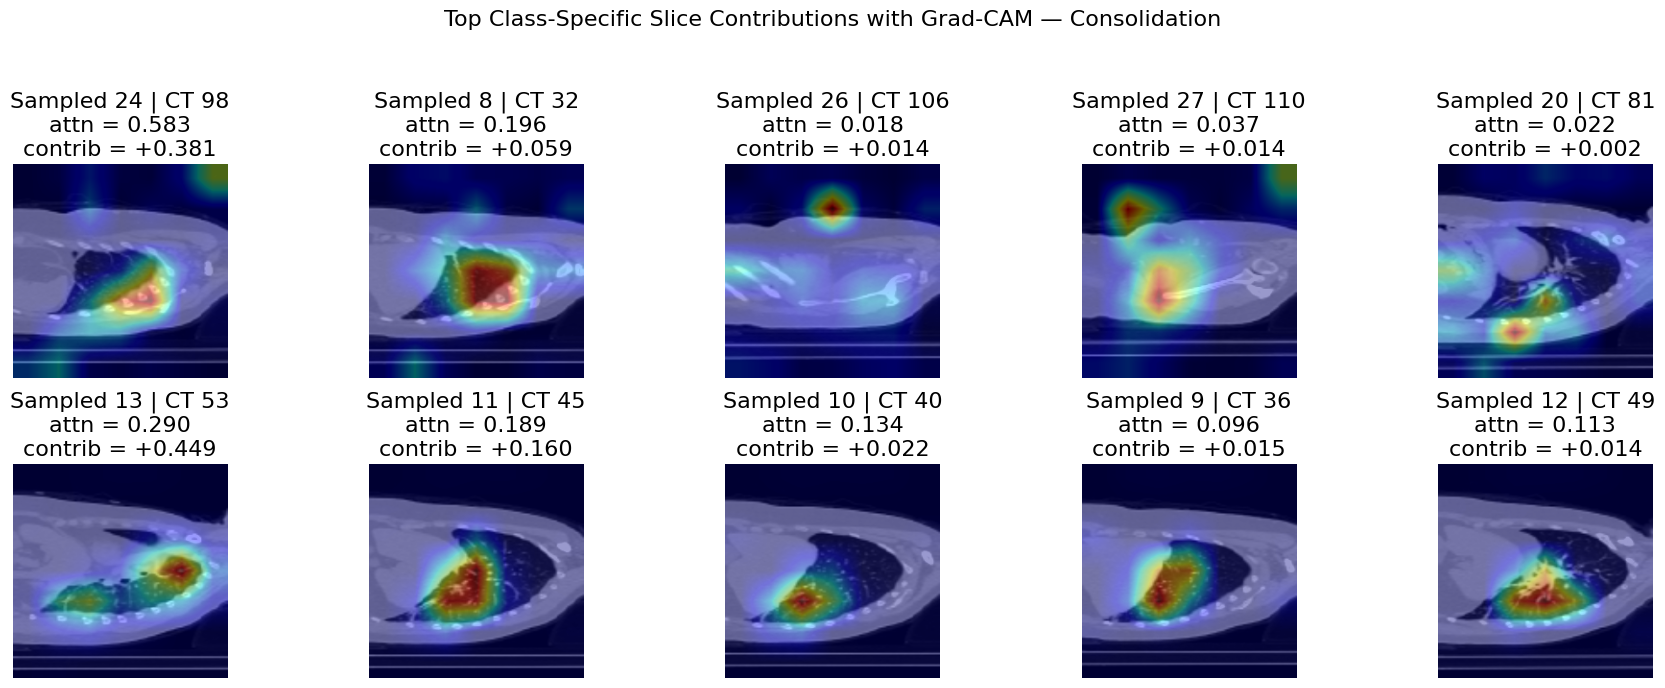

In [81]:
# ---------------------------------------------------------
# Top class-specific contributing slices + Grad-CAM
# Frozen vs Fine-tuned — Consolidation
# ---------------------------------------------------------

TOP_K = 5

# Sort by POSITIVE contribution to Consolidation
top_frozen_contrib = np.argsort(
    frozen_contributions
)[::-1][:TOP_K]

top_finetuned_contrib = np.argsort(
    finetuned_contributions
)[::-1][:TOP_K]


fig, axes = plt.subplots(
    2,
    TOP_K,
    figsize=(18, 7)
)


# =========================================================
# FROZEN
# =========================================================

for col, slice_idx in enumerate(top_frozen_contrib):

    slice_idx = int(slice_idx)

    img, cam = generate_corrected_gradcam(
        cam_frozen_correct,
        single_slice_frozen,
        slice_idx,
        class_idx
    )

    axes[0, col].imshow(
        img,
        cmap="gray",
        vmin=-1000,
        vmax=400
    )

    axes[0, col].imshow(
        cam,
        cmap="jet",
        alpha=0.4,
        vmin=0,
        vmax=1
    )

    # Original location in 128-slice volume
    original_idx = int(sampled_indices[slice_idx])

    axes[0, col].set_title(
        f"Sampled {slice_idx} | CT {original_idx}\n"
        f"attn = {frozen_attention[slice_idx]:.3f}\n"
        f"contrib = {frozen_contributions[slice_idx]:+.3f}"
    )

    axes[0, col].axis("off")


# =========================================================
# FINE-TUNED
# =========================================================

for col, slice_idx in enumerate(top_finetuned_contrib):

    slice_idx = int(slice_idx)

    img, cam = generate_corrected_gradcam(
        cam_finetuned_correct,
        single_slice_finetuned,
        slice_idx,
        class_idx
    )

    axes[1, col].imshow(
        img,
        cmap="gray",
        vmin=-1000,
        vmax=400
    )

    axes[1, col].imshow(
        cam,
        cmap="jet",
        alpha=0.4,
        vmin=0,
        vmax=1
    )

    original_idx = int(sampled_indices[slice_idx])

    axes[1, col].set_title(
        f"Sampled {slice_idx} | CT {original_idx}\n"
        f"attn = {finetuned_attention[slice_idx]:.3f}\n"
        f"contrib = {finetuned_contributions[slice_idx]:+.3f}"
    )

    axes[1, col].axis("off")


# Row labels
axes[0, 0].set_ylabel(
    "Frozen",
    fontsize=15
)

axes[1, 0].set_ylabel(
    "Fine-tuned",
    fontsize=15
)

plt.suptitle(
    "Top Class-Specific Slice Contributions with Grad-CAM — Consolidation",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

In [82]:
# ---------------------------------------------------------
# How concentrated is the positive class evidence?
# ---------------------------------------------------------

def contribution_summary(contributions, name):
    positive = np.clip(contributions, 0, None)

    total_positive = positive.sum()

    order = np.argsort(positive)[::-1]

    cumulative = np.cumsum(positive[order]) / (
        total_positive + 1e-8
    )

    print(f"\n{name}")
    print(f"Total positive contribution: {total_positive:.4f}")

    for k in [1, 2, 3, 5]:
        print(
            f"Top {k} slices account for "
            f"{100*cumulative[k-1]:.1f}% "
            f"of positive evidence"
        )


contribution_summary(
    frozen_contributions,
    "Frozen"
)

contribution_summary(
    finetuned_contributions,
    "Fine-tuned"
)


Frozen
Total positive contribution: 0.4742
Top 1 slices account for 80.4% of positive evidence
Top 2 slices account for 92.8% of positive evidence
Top 3 slices account for 95.8% of positive evidence
Top 5 slices account for 99.2% of positive evidence

Fine-tuned
Total positive contribution: 0.6708
Top 1 slices account for 66.9% of positive evidence
Top 2 slices account for 90.8% of positive evidence
Top 3 slices account for 94.1% of positive evidence
Top 5 slices account for 98.5% of positive evidence


In [83]:
from pathlib import Path

# ---------------------------------------------------------
# Find available Consolidation-positive CTs
# ---------------------------------------------------------

DATA_ROOT = Path("../dataset/CT-RATE-sample/dataset/train")

# Build lookup:
# filename -> complete path
volume_paths = {
    p.name: p
    for p in DATA_ROOT.rglob("*.nii.gz")
}

print(f"Found {len(volume_paths)} CT volumes on disk.")


# Positive according to the CT-RATE label file
consolidation_positive = labels_df[
    labels_df["Consolidation"] == 1
].copy()

# Keep only volumes actually present in our local sample dataset
consolidation_positive["path"] = consolidation_positive[
    "VolumeName"
].map(volume_paths)

available_positive = consolidation_positive[
    consolidation_positive["path"].notna()
].copy()

print(
    f"Consolidation-positive scans available locally: "
    f"{len(available_positive)}"
)

display(
    available_positive[
        ["VolumeName", "Consolidation", "path"]
    ].head(20)
)

Found 2 CT volumes on disk.
Consolidation-positive scans available locally: 2


,VolumeName,Consolidation,path
0,train_1_a_1.nii.gz,1,..\dataset\CT-RATE-sample\dataset\train\train_...
1,train_1_a_2.nii.gz,1,..\dataset\CT-RATE-sample\dataset\train\train_...


Analysing: train_1_a_2.nii.gz
Path: ..\dataset\CT-RATE-sample\dataset\train\train_1\train_1_a\train_1_a_2.nii.gz
Input shape: torch.Size([1, 32, 3, 224, 224])

Consolidation probability:
Frozen:     0.538
Fine-tuned: 0.724

FROZEN
Actual logit:        0.152969
Reconstructed logit: 0.152969

FINE-TUNED
Actual logit:        0.965125
Reconstructed logit: 0.965126

Top frozen slices contributing to Consolidation:
Slice 23: attention=0.2096, score=0.3361, contribution=+0.0704
Slice  8: attention=0.0797, score=0.4384, contribution=+0.0349
Slice  7: attention=0.0682, score=0.3912, contribution=+0.0267
Slice 10: attention=0.1868, score=0.1004, contribution=+0.0188
Slice 21: attention=0.0566, score=0.2271, contribution=+0.0129

Top fine-tuned slices contributing to Consolidation:
Slice 11: attention=0.4196, score=1.3993, contribution=+0.5872
Slice 10: attention=0.2539, score=0.6624, contribution=+0.1682
Slice 21: attention=0.1437, score=0.4999, contribution=+0.0718
Slice 13: attention=0.0506, s

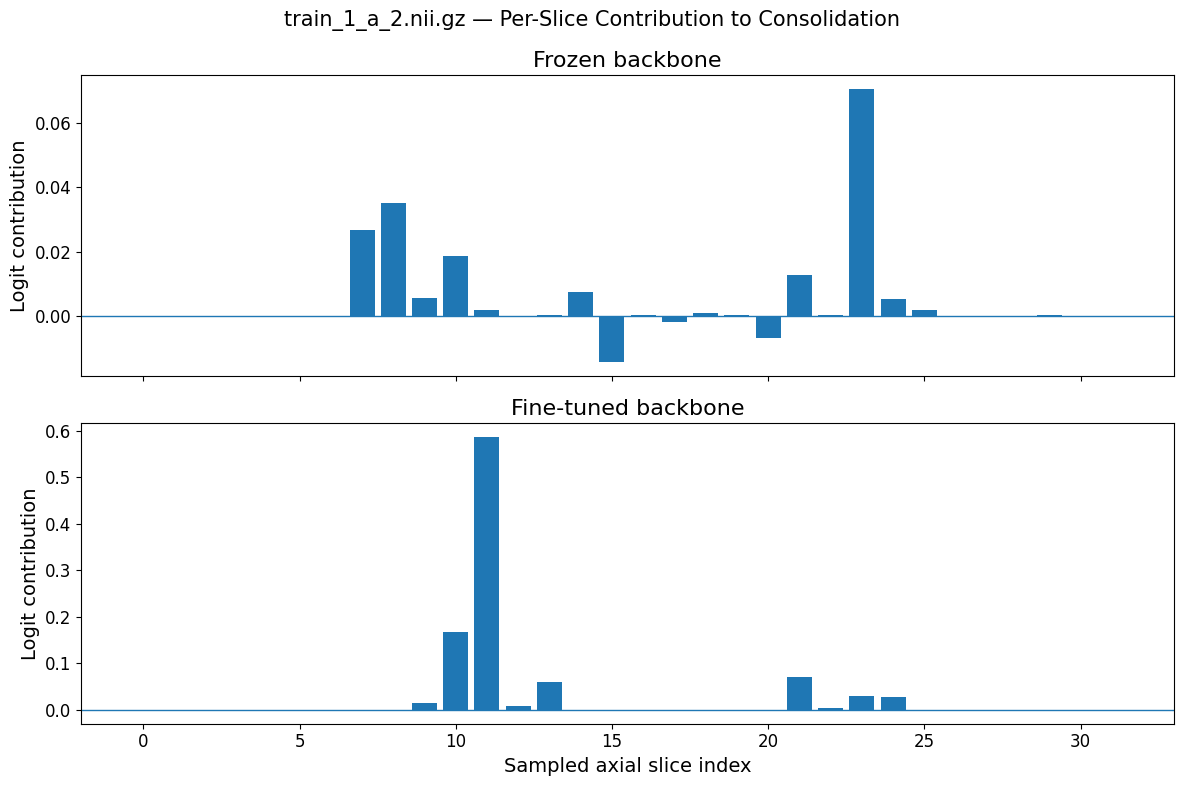

In [84]:
# ---------------------------------------------------------
# Analyse second Consolidation-positive scan
# train_1_a_2.nii.gz
# ---------------------------------------------------------

second_scan_path = available_positive.iloc[1]["path"]
second_scan_name = available_positive.iloc[1]["VolumeName"]

print("Analysing:", second_scan_name)
print("Path:", second_scan_path)


# ---------------------------------------------------------
# Load + preprocess exactly as before
# ---------------------------------------------------------

sample_data_2 = volume_transforms({
    "image": str(second_scan_path)
})

volume_hu_2 = sample_data_2["image"]

if hasattr(volume_hu_2, "as_tensor"):
    volume_hu_2 = volume_hu_2.as_tensor()

# CT-RATE local sample retains +8192 offset
volume_hu_2 = volume_hu_2 - 8192

slices_input_2 = (
    volume_to_multiwindow_slices(volume_hu_2)
    .unsqueeze(0)
    .to(device)
)

print("Input shape:", slices_input_2.shape)


# ---------------------------------------------------------
# Predictions
# ---------------------------------------------------------

with torch.no_grad():

    logits_frozen_2, attn_frozen_2 = model4_frozen(
        slices_input_2
    )

    logits_finetuned_2, attn_finetuned_2 = model4_finetuned(
        slices_input_2
    )


probs_frozen_2 = torch.sigmoid(
    logits_frozen_2
)[0].cpu().numpy()

probs_finetuned_2 = torch.sigmoid(
    logits_finetuned_2
)[0].cpu().numpy()


print(
    f"\nConsolidation probability:"
)

print(
    f"Frozen:     {probs_frozen_2[class_idx]:.3f}"
)

print(
    f"Fine-tuned: {probs_finetuned_2[class_idx]:.3f}"
)


# ---------------------------------------------------------
# Exact class-specific contributions
# ---------------------------------------------------------

(
    frozen_attention_2,
    frozen_slice_scores_2,
    frozen_contributions_2,
    frozen_reconstructed_2,
    frozen_actual_2
) = get_slice_contributions(
    model4_frozen,
    slices_input_2,
    class_idx
)


(
    finetuned_attention_2,
    finetuned_slice_scores_2,
    finetuned_contributions_2,
    finetuned_reconstructed_2,
    finetuned_actual_2
) = get_slice_contributions(
    model4_finetuned,
    slices_input_2,
    class_idx
)


# ---------------------------------------------------------
# Sanity check
# ---------------------------------------------------------

print("\nFROZEN")
print(
    f"Actual logit:        {frozen_actual_2:.6f}"
)
print(
    f"Reconstructed logit: {frozen_reconstructed_2:.6f}"
)

print("\nFINE-TUNED")
print(
    f"Actual logit:        {finetuned_actual_2:.6f}"
)
print(
    f"Reconstructed logit: {finetuned_reconstructed_2:.6f}"
)


# ---------------------------------------------------------
# Top positive contributors
# ---------------------------------------------------------

top_frozen_2 = np.argsort(
    frozen_contributions_2
)[::-1][:5]

top_finetuned_2 = np.argsort(
    finetuned_contributions_2
)[::-1][:5]


print(
    "\nTop frozen slices contributing to Consolidation:"
)

for s in top_frozen_2:

    print(
        f"Slice {s:2d}: "
        f"attention={frozen_attention_2[s]:.4f}, "
        f"score={frozen_slice_scores_2[s]:.4f}, "
        f"contribution={frozen_contributions_2[s]:+.4f}"
    )


print(
    "\nTop fine-tuned slices contributing to Consolidation:"
)

for s in top_finetuned_2:

    print(
        f"Slice {s:2d}: "
        f"attention={finetuned_attention_2[s]:.4f}, "
        f"score={finetuned_slice_scores_2[s]:.4f}, "
        f"contribution={finetuned_contributions_2[s]:+.4f}"
    )


# ---------------------------------------------------------
# Plot contribution profiles
# ---------------------------------------------------------

slice_indices = np.arange(NUM_SLICES)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 8),
    sharex=True
)


axes[0].bar(
    slice_indices,
    frozen_contributions_2
)

axes[0].axhline(
    0,
    linewidth=1
)

axes[0].set_ylabel(
    "Logit contribution"
)

axes[0].set_title(
    "Frozen backbone"
)


axes[1].bar(
    slice_indices,
    finetuned_contributions_2
)

axes[1].axhline(
    0,
    linewidth=1
)

axes[1].set_xlabel(
    "Sampled axial slice index"
)

axes[1].set_ylabel(
    "Logit contribution"
)

axes[1].set_title(
    "Fine-tuned backbone"
)


plt.suptitle(
    f"{second_scan_name} — "
    f"Per-Slice Contribution to Consolidation",
    fontsize=15
)

plt.tight_layout()
plt.show()


Frozen — scan 2
Total positive contribution: 0.1886
Top 1 slices account for 37.3% of positive evidence
Top 2 slices account for 55.9% of positive evidence
Top 3 slices account for 70.0% of positive evidence
Top 5 slices account for 86.8% of positive evidence

Fine-tuned — scan 2
Total positive contribution: 0.9745
Top 1 slices account for 60.2% of positive evidence
Top 2 slices account for 77.5% of positive evidence
Top 3 slices account for 84.9% of positive evidence
Top 5 slices account for 94.2% of positive evidence


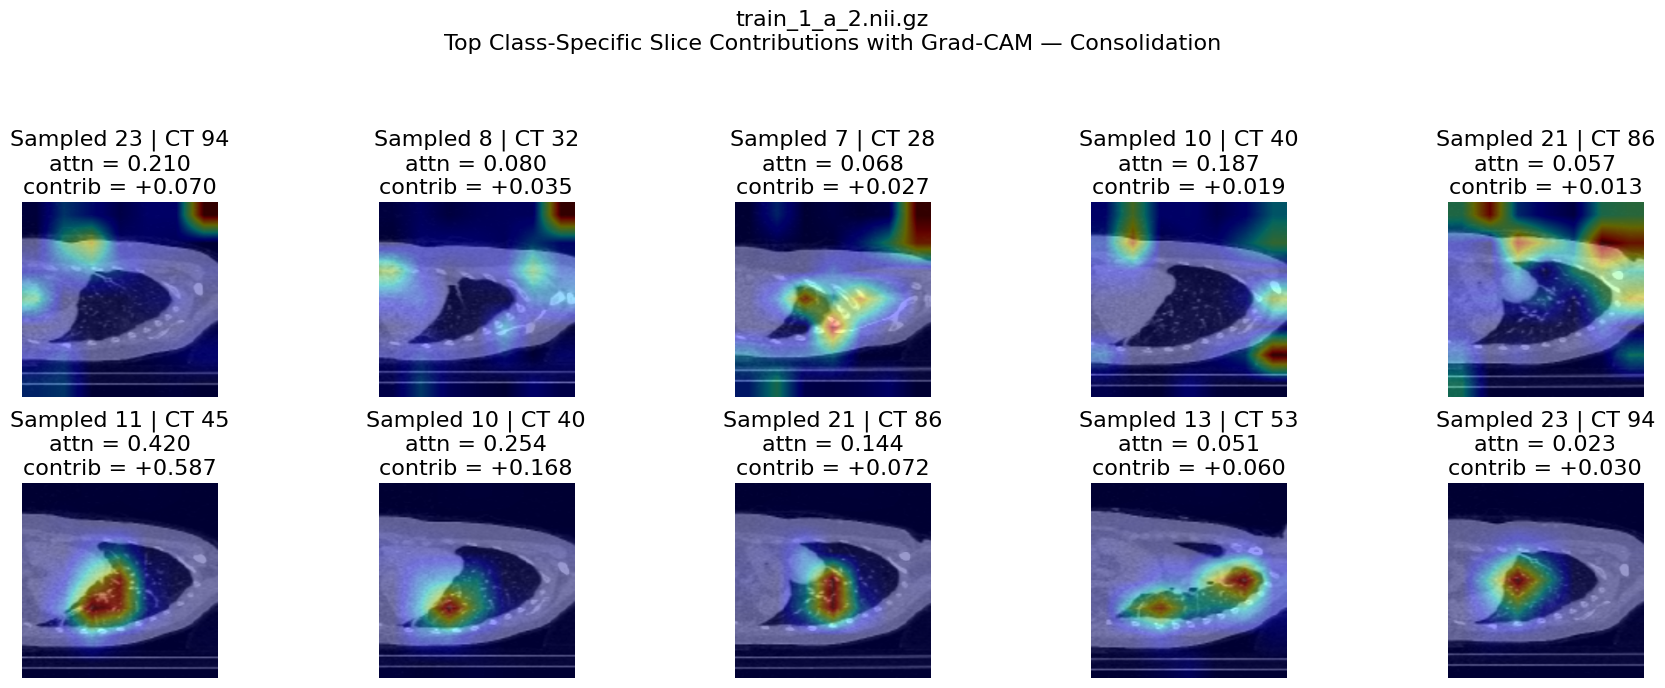

In [85]:
# ---------------------------------------------------------
# Scan-safe Grad-CAM function
# Then visualise top class-specific contributors for scan 2
# ---------------------------------------------------------

def generate_gradcam_for_scan(
    cam_object,
    model,
    slices_input_scan,
    volume_hu_scan,
    sampled_slice_idx,
    class_idx
):
    """
    Generate corrected Grad-CAM for a specific scan and sampled slice.
    """

    # -----------------------------------------------------
    # Extract model input for this sampled slice
    # -----------------------------------------------------
    slice_tensor = (
        slices_input_scan[0, sampled_slice_idx]
        .unsqueeze(0)
        .clone()
        .detach()
        .requires_grad_(True)
    )

    model.zero_grad(set_to_none=True)

    # -----------------------------------------------------
    # Grad-CAM
    # -----------------------------------------------------
    heatmap = cam_object(
        x=slice_tensor,
        class_idx=class_idx
    )[0, 0]

    # Positive Grad-CAM evidence only
    heatmap = torch.relu(heatmap)

    # Normalise independently to 0–1
    heatmap = heatmap - heatmap.min()
    heatmap = heatmap / (heatmap.max() + 1e-8)

    heatmap = heatmap.detach().cpu().numpy()


    # -----------------------------------------------------
    # Convert sampled-slice index back to resized
    # 128-slice CT-volume index
    # -----------------------------------------------------
    sampled_indices_scan = torch.linspace(
        0,
        volume_hu_scan.shape[1] - 1,
        NUM_SLICES
    ).long()

    volume_idx = int(
        sampled_indices_scan[sampled_slice_idx]
    )


    # -----------------------------------------------------
    # Original CT slice for display
    # -----------------------------------------------------
    raw_slice = (
        volume_hu_scan[0, volume_idx]
        .unsqueeze(0)
        .unsqueeze(0)
        .float()
    )

    display_slice = F.interpolate(
        raw_slice,
        size=(SLICE_SIZE, SLICE_SIZE),
        mode="bilinear",
        align_corners=False
    )[0, 0].cpu().numpy()

    return display_slice, heatmap, volume_idx


# =========================================================
# Positive evidence concentration for scan 2
# =========================================================

def contribution_summary(contributions, name):

    positive = np.clip(
        contributions,
        0,
        None
    )

    total_positive = positive.sum()

    order = np.argsort(
        positive
    )[::-1]

    cumulative = (
        np.cumsum(positive[order])
        / (total_positive + 1e-8)
    )

    print(f"\n{name}")
    print(
        f"Total positive contribution: "
        f"{total_positive:.4f}"
    )

    for k in [1, 2, 3, 5]:
        print(
            f"Top {k} slices account for "
            f"{100*cumulative[k-1]:.1f}% "
            f"of positive evidence"
        )


contribution_summary(
    frozen_contributions_2,
    "Frozen — scan 2"
)

contribution_summary(
    finetuned_contributions_2,
    "Fine-tuned — scan 2"
)


# =========================================================
# Top contributors
# =========================================================

TOP_K = 5

top_frozen_2 = np.argsort(
    frozen_contributions_2
)[::-1][:TOP_K]

top_finetuned_2 = np.argsort(
    finetuned_contributions_2
)[::-1][:TOP_K]


# =========================================================
# Grad-CAM montage
# =========================================================

fig, axes = plt.subplots(
    2,
    TOP_K,
    figsize=(18, 7)
)


# ---------------------------------------------------------
# Frozen
# ---------------------------------------------------------

for col, slice_idx in enumerate(top_frozen_2):

    slice_idx = int(slice_idx)

    img, cam, ct_idx = generate_gradcam_for_scan(
        cam_frozen_correct,
        single_slice_frozen,
        slices_input_2,
        volume_hu_2,
        slice_idx,
        class_idx
    )

    axes[0, col].imshow(
        img,
        cmap="gray",
        vmin=-1000,
        vmax=400
    )

    axes[0, col].imshow(
        cam,
        cmap="jet",
        alpha=0.4,
        vmin=0,
        vmax=1
    )

    axes[0, col].set_title(
        f"Sampled {slice_idx} | CT {ct_idx}\n"
        f"attn = {frozen_attention_2[slice_idx]:.3f}\n"
        f"contrib = {frozen_contributions_2[slice_idx]:+.3f}"
    )

    axes[0, col].axis("off")


# ---------------------------------------------------------
# Fine-tuned
# ---------------------------------------------------------

for col, slice_idx in enumerate(top_finetuned_2):

    slice_idx = int(slice_idx)

    img, cam, ct_idx = generate_gradcam_for_scan(
        cam_finetuned_correct,
        single_slice_finetuned,
        slices_input_2,
        volume_hu_2,
        slice_idx,
        class_idx
    )

    axes[1, col].imshow(
        img,
        cmap="gray",
        vmin=-1000,
        vmax=400
    )

    axes[1, col].imshow(
        cam,
        cmap="jet",
        alpha=0.4,
        vmin=0,
        vmax=1
    )

    axes[1, col].set_title(
        f"Sampled {slice_idx} | CT {ct_idx}\n"
        f"attn = {finetuned_attention_2[slice_idx]:.3f}\n"
        f"contrib = {finetuned_contributions_2[slice_idx]:+.3f}"
    )

    axes[1, col].axis("off")


axes[0, 0].set_ylabel(
    "Frozen",
    fontsize=15
)

axes[1, 0].set_ylabel(
    "Fine-tuned",
    fontsize=15
)

plt.suptitle(
    f"{second_scan_name}\n"
    f"Top Class-Specific Slice Contributions "
    f"with Grad-CAM — Consolidation",
    fontsize=16
)

plt.tight_layout(
    rect=[0, 0, 1, 0.92]
)

plt.show()

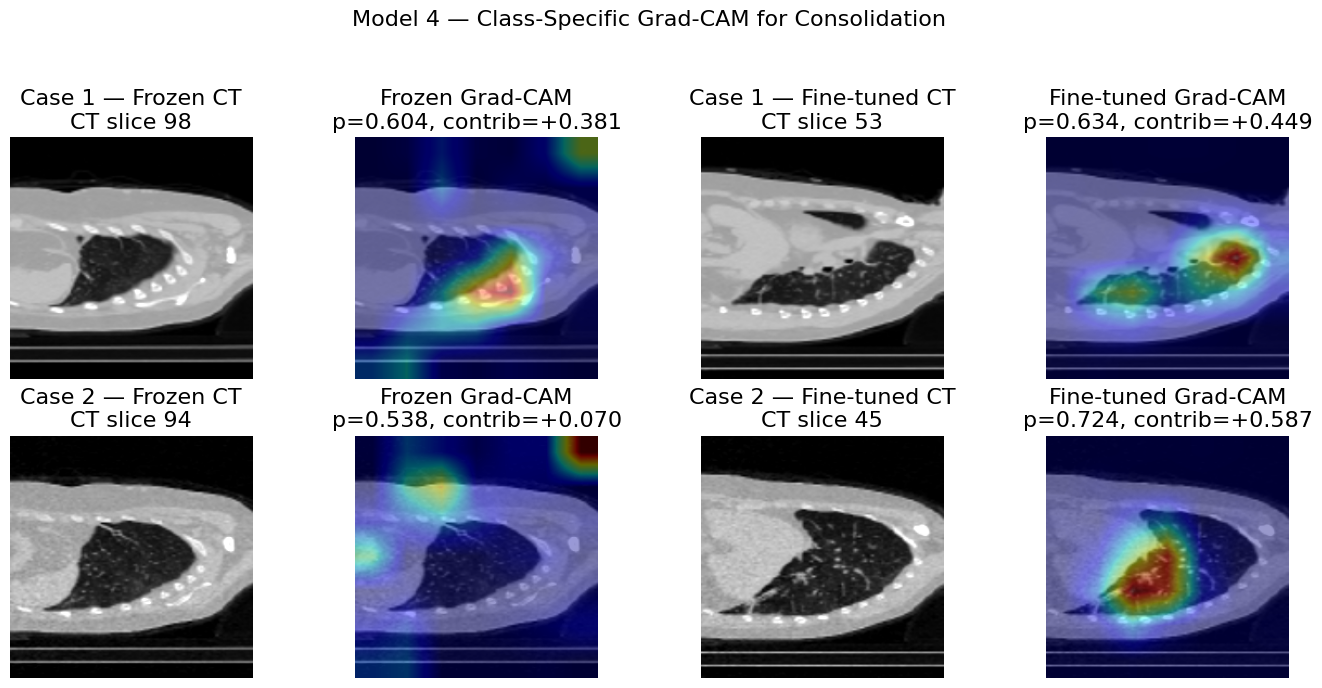

In [86]:
# =========================================================
# FINAL QUALITATIVE COMPARISON FIGURE
# Two Consolidation-positive cases
#
# Columns:
# Frozen CT | Frozen Grad-CAM | Fine-tuned CT | Fine-tuned Grad-CAM
# =========================================================

cases = [
    {
        "name": "Case 1",
        "slices_input": slices_input,
        "volume_hu": volume_hu,
        "frozen_contributions": frozen_contributions,
        "finetuned_contributions": finetuned_contributions,
        "frozen_attention": frozen_attention,
        "finetuned_attention": finetuned_attention,
        "frozen_prob": probs_frozen[class_idx],
        "finetuned_prob": probs_finetuned[class_idx],
    },

    {
        "name": "Case 2",
        "slices_input": slices_input_2,
        "volume_hu": volume_hu_2,
        "frozen_contributions": frozen_contributions_2,
        "finetuned_contributions": finetuned_contributions_2,
        "frozen_attention": frozen_attention_2,
        "finetuned_attention": finetuned_attention_2,
        "frozen_prob": probs_frozen_2[class_idx],
        "finetuned_prob": probs_finetuned_2[class_idx],
    }
]


fig, axes = plt.subplots(
    2,
    4,
    figsize=(14, 7)
)


for row, case in enumerate(cases):

    # -----------------------------------------------------
    # Highest POSITIVE class-specific contributor
    # -----------------------------------------------------

    frozen_idx = int(
        np.argmax(case["frozen_contributions"])
    )

    finetuned_idx = int(
        np.argmax(case["finetuned_contributions"])
    )


    # -----------------------------------------------------
    # Frozen Grad-CAM
    # -----------------------------------------------------

    frozen_img, frozen_cam, frozen_ct_idx = (
        generate_gradcam_for_scan(
            cam_frozen_correct,
            single_slice_frozen,
            case["slices_input"],
            case["volume_hu"],
            frozen_idx,
            class_idx
        )
    )


    # -----------------------------------------------------
    # Fine-tuned Grad-CAM
    # -----------------------------------------------------

    finetuned_img, finetuned_cam, finetuned_ct_idx = (
        generate_gradcam_for_scan(
            cam_finetuned_correct,
            single_slice_finetuned,
            case["slices_input"],
            case["volume_hu"],
            finetuned_idx,
            class_idx
        )
    )


    # =====================================================
    # Frozen raw CT
    # =====================================================

    axes[row, 0].imshow(
        frozen_img,
        cmap="gray",
        vmin=-1000,
        vmax=400
    )

    axes[row, 0].set_title(
        f"{case['name']} — Frozen CT\n"
        f"CT slice {frozen_ct_idx}"
    )

    axes[row, 0].axis("off")


    # =====================================================
    # Frozen Grad-CAM
    # =====================================================

    axes[row, 1].imshow(
        frozen_img,
        cmap="gray",
        vmin=-1000,
        vmax=400
    )

    axes[row, 1].imshow(
        frozen_cam,
        cmap="jet",
        alpha=0.4,
        vmin=0,
        vmax=1
    )

    axes[row, 1].set_title(
        f"Frozen Grad-CAM\n"
        f"p={case['frozen_prob']:.3f}, "
        f"contrib={case['frozen_contributions'][frozen_idx]:+.3f}"
    )

    axes[row, 1].axis("off")


    # =====================================================
    # Fine-tuned raw CT
    # =====================================================

    axes[row, 2].imshow(
        finetuned_img,
        cmap="gray",
        vmin=-1000,
        vmax=400
    )

    axes[row, 2].set_title(
        f"{case['name']} — Fine-tuned CT\n"
        f"CT slice {finetuned_ct_idx}"
    )

    axes[row, 2].axis("off")


    # =====================================================
    # Fine-tuned Grad-CAM
    # =====================================================

    axes[row, 3].imshow(
        finetuned_img,
        cmap="gray",
        vmin=-1000,
        vmax=400
    )

    axes[row, 3].imshow(
        finetuned_cam,
        cmap="jet",
        alpha=0.4,
        vmin=0,
        vmax=1
    )

    axes[row, 3].set_title(
        f"Fine-tuned Grad-CAM\n"
        f"p={case['finetuned_prob']:.3f}, "
        f"contrib={case['finetuned_contributions'][finetuned_idx]:+.3f}"
    )

    axes[row, 3].axis("off")


plt.suptitle(
    "Model 4 — Class-Specific Grad-CAM for Consolidation",
    fontsize=16
)

plt.tight_layout(
    rect=[0, 0, 1, 0.94]
)

plt.show()